In [19]:
# Import libraries
import numpy as np                          # for scientific computing and array analysis
import pandas as pd                         # for working with data structures
import matplotlib.pyplot as plt             # for 2D plotting
import seaborn as sns                       # for enhanced data visualization
import os                                   # for interacting with the operating system
import random                               # for pseudo-random number generators
import timeit                               # for timing code execution

# SciPy modules
from scipy.integrate import odeint          # for working with ordinary differential equations
from scipy.optimize import minimize         # for minimization
import scipy.stats as stats                 # for statistical functions
import scipy.signal as sg                   # for signal processing

# Machine Learning and Statistics
from sklearn.metrics import mean_squared_error, r2_score # for model evaluation metrics
import statsmodels.api as sm                # for statistical models, including autocorrelation function

# Animation (if needed)
from matplotlib.animation import FuncAnimation

# Google Colab file access (only if using Google Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Ignore if not in Google Colab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Data Preprocessing

In [20]:
########### Data Processing ##################
##############################################

np.random.seed(42)

# Data Preprocessing Function
def preprocess_data(file_path, gauge_ids_of_interest, years):

    # Load data
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])

    # Get the start date for each gauge station
    start_dates = df.groupby('gauge_id')['date'].min().reset_index()
    start_dates.columns = ['gauge_id', 'start_date']

    # Merge the start dates back to the original dataframe
    df = df.merge(start_dates, on='gauge_id')

    # Calculate the end date for the specified period from the start date
    df['end_date'] = df['start_date'] + pd.DateOffset(years=years)

    # Filter the dataset for the specified range
    df = df[(df['date'] >= df['start_date']) & (df['date'] < df['end_date'])]

    # Drop the helper columns
    df = df.drop(columns=['start_date', 'end_date'])

    # Subset the DataFrame to include only rows with the specified gauge IDs and sort by date
    df = df[df['gauge_id'].isin(gauge_ids_of_interest)].sort_values(by=['gauge_id', 'date'])

    # Normalize streamflow by dividing by its mean
    df['streamflow'] = df['streamflow'] / df['streamflow'].mean()

    return df

#ODE Parameter Learning

In [ ]:
########### ODE Block ##############
####################################

# Define the ODE model
def ode(par, rain, Temp, dt=1, T=3640):
    n = int(T / dt)
    x = np.zeros(n)
    Qeff = np.zeros(n)
    A, b, k, Qref, bf = par
    epsilon = 1e-6

    for i in range(n - 1):
        try:
            x[i + 1] = max(0, bf + x[i] +
                           (rain[i] - Qref * ((x[i] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt)
            x[i + 1] = min(x[i + 1], 1e6)  # Clamp to avoid extreme values
        except OverflowError:
            x[i + 1] = 0

    try:
        Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    except OverflowError:
        Qeff[:] = np.nan

    Qeff[np.isnan(Qeff) | np.isinf(Qeff)] = 0
    return Qeff

# Objective function
def objective_function(params, rain, Temp, observed_discharge, dt, T):
    modeled_discharge = ode(params, rain, Temp, dt=dt, T=T)
    if np.any(np.isnan(modeled_discharge)) or np.any(np.isinf(modeled_discharge)):
        return np.inf
    return mean_squared_error(observed_discharge[:len(modeled_discharge)], modeled_discharge)

# Adam Optimizer
def adam_optimizer(objective_function, rain, Temp, observed_discharge, dt, T, initial_params, learning_rate, n_iter, beta1=0.9, beta2=0.999, epsilon=1e-8):
    params = np.array(initial_params)
    m = np.zeros_like(params)
    v = np.zeros_like(params)
    t = 0

    for _ in range(n_iter):
        t += 1
        grad = np.zeros_like(params)
        epsilon_grad = 1e-5

        for i in range(len(params)):
            params_eps = np.array(params)
            params_eps[i] += epsilon_grad
            loss_eps = objective_function(params_eps, rain, Temp, observed_discharge, dt, T)
            loss = objective_function(params, rain, Temp, observed_discharge, dt, T)
            grad[i] = (loss_eps - loss) / epsilon_grad

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        params -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

    modeled_discharge = ode(params, rain, Temp, dt=dt, T=T)
    final_r2 = r2_score(observed_discharge[:len(modeled_discharge)], modeled_discharge)
    return params, final_r2

# Plotting Function
def plot_results(observed_discharge, modeled_discharge, gauge_id, save_plot=False):
    plt.figure(figsize=(10, 6))
    plt.plot(observed_discharge[:len(modeled_discharge)], '.', color='black', label='Observed Discharge')
    plt.plot(modeled_discharge, label='Modeled Discharge', color='red')
    plt.title(f'Observed vs Modeled Discharge for Gauge ID: {gauge_id}')
    plt.xlabel('Time Steps')
    plt.ylabel('Discharge (Q/Q_mean)')
    plt.legend()

    if save_plot:
        plt.savefig(f'gauge_{gauge_id}_performance.png')
    plt.show()

############## Main Execution Block ##################
######################################################

file_path = '/content/drive/My Drive/CAMEL_ML/Full_dataset_Updated_Shah.csv'
years = 5
learning_rate = 0.005
n_iter = 30000

gauge_params = {
    2231000: [0.5409783, 1.26243935, 14.50110925, 0.20632286, -1.98565057],
    2479560: [0.42620015, 1.47849264, 12.68285738, 0.13409962, -2.70999464],
    2472000: [0.54610482, 1.63992837, 14.45826801, 0.02097041, -2.66361643],
    2324400: [0.54175699, 1.39703607, 12.35372607, 0.12964449, -2.47279016],
    2314500: [2.03315095, 1.52049421, 14.5421711, 0.01404076, -3.74390583]
}

# Preprocess the data
gauge_ids_of_interest = list(gauge_params.keys())
data = preprocess_data(file_path, gauge_ids_of_interest, years)

results = {}
for gauge_id, initial_params in gauge_params.items():
    print(f"Processing Gauge ID: {gauge_id}")
    gauge_data = data[data['gauge_id'] == gauge_id]
    rain = gauge_data['prcp'].values
    Temp = gauge_data['tmax'].values
    observed_discharge = gauge_data['streamflow'].values
    dt = (gauge_data['date'].iloc[1] - gauge_data['date'].iloc[0]).days
    T = (gauge_data['date'].iloc[-1] - gauge_data['date'].iloc[0]).days

    best_params, r_squared = adam_optimizer(
        objective_function, rain, Temp, observed_discharge, dt, T,
        initial_params, learning_rate, n_iter
    )

    results[gauge_id] = {
        "Best Parameters": best_params,
        "R-squared": r_squared
    }

    print(f"Gauge ID: {gauge_id}")
    print("Best Parameters:", best_params)
    print(f"R-squared: {r_squared:.4f}")

    modeled_discharge = ode(best_params, rain, Temp, dt=dt, T=T)
    plot_results(observed_discharge, modeled_discharge, gauge_id, save_plot=True)

print("\nSummary of Results:")
for gauge_id, result in results.items():
    print(f"Gauge ID: {gauge_id}")
    print("Best Parameters:", result["Best Parameters"])
    print(f"R-squared: {result['R-squared']:.4f}\n")

In [ ]:
best_params_dict = {gauge_id: result["Best Parameters"] for gauge_id, result in results.items()}
print("gauge_ids_of_interest =", list(best_params_dict.keys()))
print("best_params_dict = {")
for gauge_id, params in best_params_dict.items():
    print(f"    {gauge_id}: {params},")
print("}")

#ODE Deployment

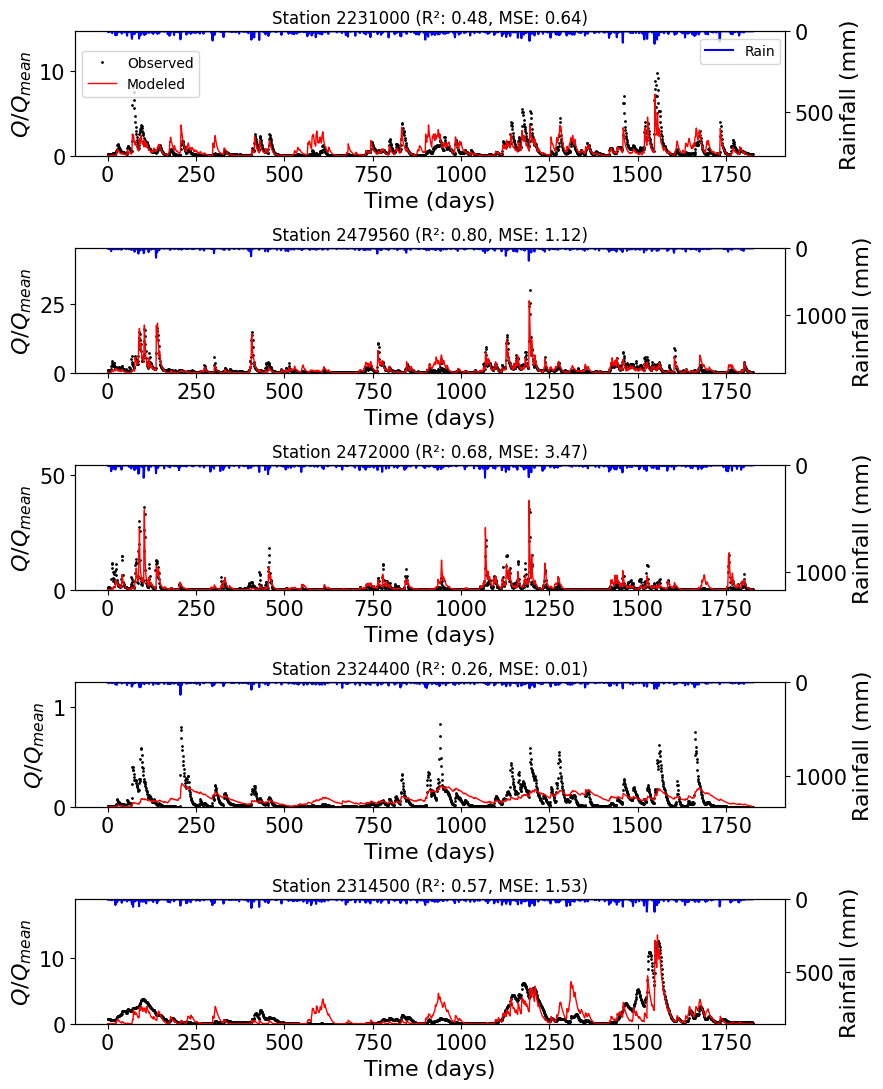

In [21]:
########## ODE Model Definition #############
#############################################

# def ode(par, rain, Temp, dt=1, T=3640):
#     n = int(T / dt)
#     x = np.zeros(n)
#     Qeff = np.ones(n)
#     A, b, k, Qref, bf = par
#     epsilon = 1e-6
#     for i in range(n - 1):
#         x[i + 1] = max(0, bf + x[i] + (rain[i] - Qref * ((x[i] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt)
#     Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
#     return Qeff


def ode(par, rain, Temp, dt=1, T=3640):
    n = int(T / dt)  # Number of time steps
    x = np.zeros(n)  # Initialize state variable
    Qeff = np.zeros(n)  # Initialize effective discharge
    A, b, k, Qref, bf = par  # Unpack parameters
    epsilon = 1e-6  # Small constant to avoid division by zero

    # Compute state variable 'x' iteratively
    for i in range(n - 1):
        try:
            x[i + 1] = max(0, bf + x[i] +
                           (rain[i] - Qref * ((x[i] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt)
            # Clamp x[i+1] to avoid extremely large values
            x[i + 1] = min(x[i + 1], 1e6)
        except OverflowError:
            x[i + 1] = 0  # Reset to avoid instability

    # Effective discharge 'Qeff'
    try:
        Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    except OverflowError:
        Qeff[:] = np.nan  # Mark as invalid

    # Replace invalid Qeff values with zero
    Qeff[np.isnan(Qeff) | np.isinf(Qeff)] = 0

    return Qeff

########### Evaluation and Plotting #########
#############################################

def evaluate_and_plot(df, gauge_ids, params_dict):
    num_stations = len(gauge_ids)
    fig, ax_left = plt.subplots(num_stations, figsize=(9, 11))

    for i, gauge_id in enumerate(gauge_ids):
        data = df[df['gauge_id'] == gauge_id]
        rain_obs = data['prcp'].values
        Temp_obs = data['tmax'].values
        discharge_obs = data['streamflow'].values
        date = data['date']

        dt = (date.iloc[1] - date.iloc[0]).days
        T = (date.iloc[-1] - date.iloc[0]).days
        if T <= 0:
            print(f"Skipping Gauge ID: {gauge_id}")
            continue

        modeled_discharge = ode(params_dict[gauge_id], rain_obs, Temp_obs, dt=dt, T=T)
        mse = mean_squared_error(discharge_obs[:len(modeled_discharge)], modeled_discharge)
        r2 = r2_score(discharge_obs[:len(modeled_discharge)], modeled_discharge)

        title = f"Station {gauge_id} (R²: {r2:.2f}, MSE: {mse:.2f})"
        ax_right = ax_left[i].twinx()
        ax_left[i].plot(discharge_obs, '.', color='black', markersize=2, label='Observed Discharge')
        ax_left[i].plot(modeled_discharge, color='red', linewidth=1, label='Modeled Discharge')
        ax_right.invert_yaxis()  # Invert the y-axis for rainfall
        ax_right.plot(rain_obs, color='blue', label='Rain')
        ax_left[i].set_ylim([0, 1.5 * max(discharge_obs)])
        ax_right.set_ylim([10 * max(rain_obs), 0])
        ax_left[i].set_xlabel('Time (days)', fontsize=16)
        ax_left[i].set_ylabel(r'$Q/Q_{mean}$', fontsize=16)
        ax_right.set_ylabel(r'Rainfall (mm)', fontsize=16)
        # Set font sizes for ticks
        ax_left[i].tick_params(axis='both', which='major', labelsize=15)
        ax_right.tick_params(axis='both', which='major', labelsize=15)
        if i == 0:
            # ax_right.legend(['Rain'], loc='upper right')
            # ax_left[i].legend(['Observed', 'Modeled'], loc='upper left')
            ax_right.legend(['Rain'], loc='upper left', bbox_to_anchor=(0.87, 1 - 0.002))
            ax_left[i].legend(['Observed', 'Modeled'], loc='upper left', bbox_to_anchor=(0, 1 - 0.1))
        ax_left[i].set_title(title)

    plt.tight_layout()
    plt.show()

########### Main Execution ##################
#############################################

file_path = '/content/drive/My Drive/CAMEL_ML/Full_dataset_Updated_Shah.csv'

gauge_ids_of_interest = [2231000, 2479560, 2472000, 2324400, 2314500]
# gauge_ids_of_interest = [1013500, 1022500, 1030500, 1031500, 1047000]

best_params_dict = {
    2231000: [0.3946042, 1.52383501, 14.83256936, 0.10079699, -1.90902814],
    2479560: [0.63096328, 1.47833247, 11.25937921, 0.10661567, -2.70666429],
    2472000: [0.84442412, 1.64037634, 12.72633699, 0.01453908, -2.66315377],
    2324400: [0.06551341, 1.25968001, 12.4877728, 0.02796022, -2.91956749],
    2314500: [2.31098545e+00, 1.52267643e+00, 1.17535060e+01, 9.18936990e-03, -3.73873583e+00],
}

years = 5

df = preprocess_data(file_path, gauge_ids_of_interest, years)
evaluate_and_plot(df, gauge_ids_of_interest, best_params_dict)

#SDE Deployment

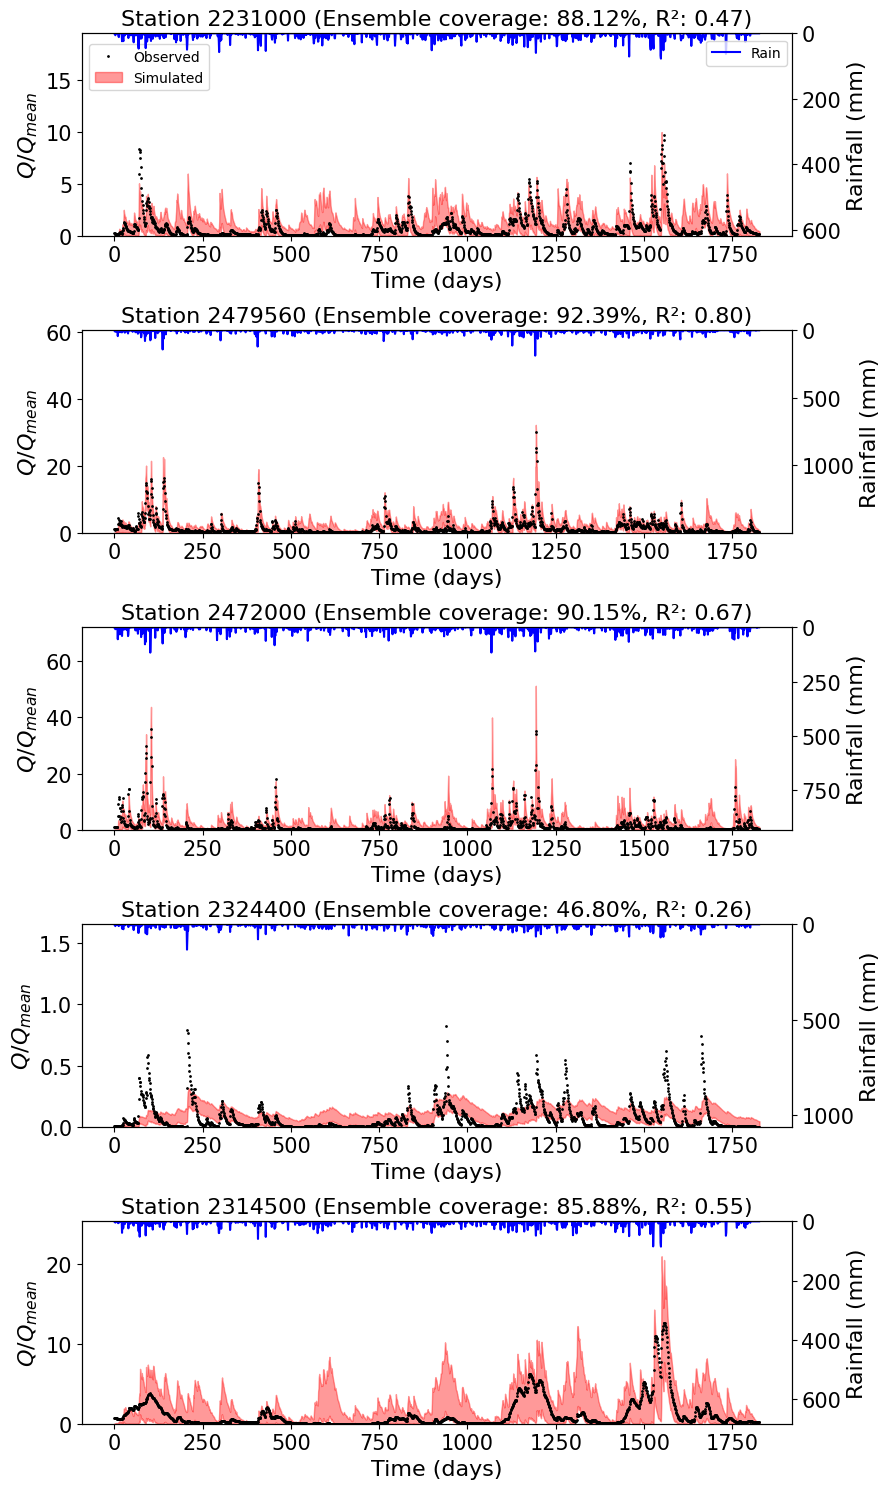

In [22]:
############### SDE Deployment Block ###############
####################################################

def sde(par, rain, Temp, runs=1000, dt=1, T=None):
    n = len(rain)  # Match the number of time steps to the input data length
    x = np.zeros((n, runs))  # State variable
    Qeff = np.ones((n, runs))  # Effective discharge
    A, b, k, Qref, bf = par
    epsilon = 1e-6

    for j in range(runs):
        for i in range(n - 1):
            noise_term = np.random.normal(0, 7 * np.sqrt(dt))
            x[i + 1, j] = max(
                0,
                bf + x[i, j] + (rain[i] - Qref * ((x[i, j] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt + noise_term
            )

    Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    return Qeff

# Function to compute coverage probability
def compute_coverage_probability(observed_discharge, modeled_discharge_all, confidence_level=0.95):
    lower_bound = np.percentile(modeled_discharge_all, (1 - confidence_level) / 2 * 100, axis=1)
    upper_bound = np.percentile(modeled_discharge_all, (1 + confidence_level) / 2 * 100, axis=1)

    within_bounds = (observed_discharge >= lower_bound) & (observed_discharge <= upper_bound)
    coverage_probability = np.mean(within_bounds)

    return coverage_probability

def evaluate_and_plot_sde_model(df, gauge_ids, params_dict, runs=1000, confidence_interval=0.95):
    fig, ax_left = plt.subplots(len(gauge_ids), figsize=(9, len(gauge_ids) * 3))
    names = []

    for i, gauge_id in enumerate(gauge_ids):
        data = df[df['gauge_id'] == gauge_id].copy()
        data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

        rain_obs = data['prcp'].values
        Temp_obs = data['tmax'].values
        discharge_obs = data['streamflow'].values
        date = data['date']

        # Handle missing data
        if len(rain_obs) == 0 or len(discharge_obs) == 0:
            print(f"No valid data for Gauge ID {gauge_id}. Skipping.")
            continue

        dt = (date.iloc[1] - date.iloc[0]).days
        T = len(rain_obs)

        # Compute modeled discharge using the SDE model
        modeled_discharge_all = sde(params_dict[gauge_id], rain_obs, Temp_obs, runs=runs, dt=dt, T=T)

        # Compute ensemble statistics
        mean_modeled_discharge = modeled_discharge_all.mean(axis=1)
        mse = mean_squared_error(discharge_obs[:len(mean_modeled_discharge)], mean_modeled_discharge)
        r2 = r2_score(discharge_obs[:len(mean_modeled_discharge)], mean_modeled_discharge)

        # Compute coverage probability
        cp = compute_coverage_probability(discharge_obs[:len(mean_modeled_discharge)], modeled_discharge_all, confidence_interval)

        # Append station name and statistics
        names.append(f"Station {gauge_id} (Ensemble coverage: {cp * 100:.2f}%, R²: {r2:.2f})")

        # Create twin y-axis for rainfall
        ax_right = ax_left[i].twinx()

        # Plot observed discharge
        ax_left[i].plot(discharge_obs, '.', color='black', markersize=2, label='Observed Discharge')

        # Plot confidence intervals for modeled discharge
        ax_left[i].fill_between(
            np.linspace(0., len(mean_modeled_discharge), len(mean_modeled_discharge)),
            np.percentile(modeled_discharge_all, (1 - confidence_interval) / 2 * 100, axis=1),
            np.percentile(modeled_discharge_all, (1 + confidence_interval) / 2 * 100, axis=1),
            color='red', alpha=0.4, label='Simulated Discharge'
        )

        # Plot rainfall
        ax_right.invert_yaxis()
        ax_right.plot(rain_obs, color='blue', label='Rain')

        # Set y-axis limits
        ax_left[i].set_ylim([0, 2.0 * max(discharge_obs)])
        ax_right.set_ylim([8 * max(rain_obs), 0])

        # Set axis labels with font size
        ax_left[i].set_xlabel('Time (days)', fontsize=16)
        ax_left[i].set_ylabel(r'$Q/Q_{mean}$', fontsize=16)
        ax_right.set_ylabel('Rainfall (mm)', fontsize=16)

        # Set font sizes for ticks
        ax_left[i].tick_params(axis='both', which='major', labelsize=15)
        ax_right.tick_params(axis='both', which='major', labelsize=15)

        # Add legends for the first subplot only
        if i == 0:
            ax_right.legend(['Rain'], loc='upper left', bbox_to_anchor=(0.87, 1 - 0.002), fontsize=10)
            ax_left[i].legend(['Observed', 'Simulated'], loc='upper left', bbox_to_anchor=(0, 1 - 0.02), fontsize=10)

        # Set title
        ax_left[i].set_title(names[i], fontsize=16)

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

# Evaluate SDE model for the gauge IDs
evaluate_and_plot_sde_model(df, gauge_ids_of_interest, best_params_dict, runs=1000, confidence_interval=0.95)


# # Define the SDE model
# def sde(par, rain, Temp, runs=10000, dt=1, T=3640):
#     n = int(T / dt)  # Number of time steps
#     x = np.zeros([n, runs])  # Initialize state variable
#     Qeff = np.ones([n, runs])  # Initialize effective discharge
#     A, b, k, Qref, bf = par  # Unpack parameters
#     epsilon = 1e-6  # Small constant to avoid division by zero

#     for j in range(runs):
#         for i in range(n - 1):
#             noise_term = np.random.normal(0, 7 * np.sqrt(dt), 1)[0]  # Introduce noise
#             x[i + 1, j] = max(
#                 0,
#                 bf + x[i, j] + (rain[i] - Qref * ((x[i, j] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt + noise_term
#             )

#     Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
#     return Qeff

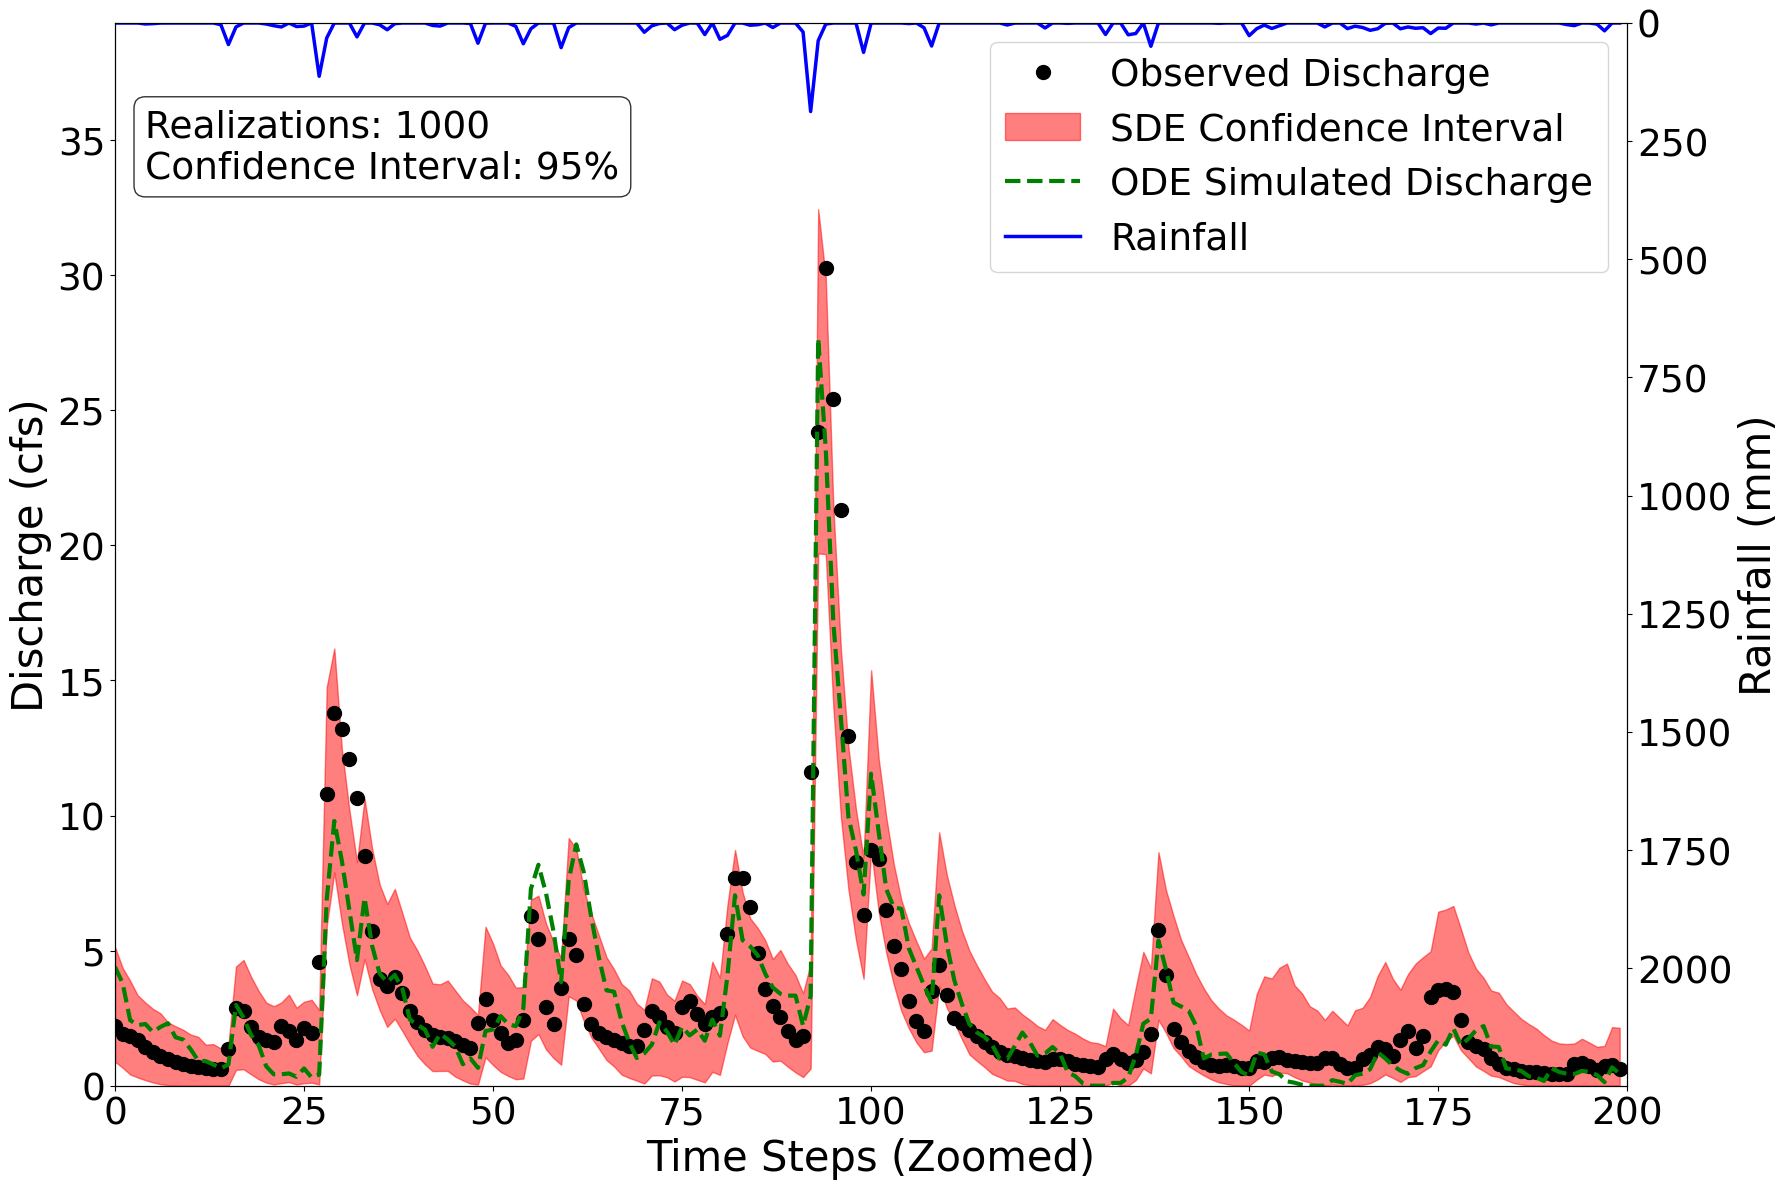

In [23]:
#### Zoomed-in Inspection ######
################################

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Function to evaluate and plot SDE and ODE model with zoomed-in section for hydrograph 2
def plot_zoomed_hydrograph_with_ode(df, gauge_ids, params_dict, runs=1000, confidence_interval=0.95, zoom_range=(1100, 1300)):
    fig, ax = plt.subplots(figsize=(18, 12))  # Adjusted figure size for better presentation

    gauge_id = gauge_ids[1]  # Assume gauge ID 2 is at index 1
    data = df[df['gauge_id'] == gauge_id].copy()
    data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

    rain_obs = data['prcp'].values
    Temp_obs = data['tmax'].values
    discharge_obs = data['streamflow'].values
    date = data['date']

    # Handle missing data
    if len(rain_obs) == 0 or len(discharge_obs) == 0:
        print(f"No valid data for Gauge ID {gauge_id}. Skipping.")
        return

    dt = (date.iloc[1] - date.iloc[0]).days
    T = len(rain_obs)

    # Compute SDE modeled discharge
    modeled_discharge_sde = sde(params_dict[gauge_id], rain_obs, Temp_obs, runs=runs, dt=dt, T=T)

    # Compute ODE modeled discharge (SDE with noise turned off)
    modeled_discharge_ode = sde(params_dict[gauge_id][:5], rain_obs, Temp_obs, runs=1, dt=dt, T=T).flatten()

    # Compute ensemble statistics
    mean_modeled_discharge_sde = modeled_discharge_sde.mean(axis=1)

    # Zoom in to the specified range
    start, end = zoom_range
    discharge_obs_zoomed = discharge_obs[start:end]
    mean_modeled_discharge_sde_zoomed = mean_modeled_discharge_sde[start:end]
    discharge_ode_zoomed = modeled_discharge_ode[start:end]
    rain_obs_zoomed = rain_obs[start:end]

    # Plot observed discharge
    ax.plot(
        np.arange(len(discharge_obs_zoomed)),
        discharge_obs_zoomed,
        'o',
        color='black',
        markersize=10,
        label='Observed Discharge'
    )

    # Plot confidence intervals for SDE modeled discharge (thicker band)
    ax.fill_between(
        np.arange(len(mean_modeled_discharge_sde_zoomed)),
        np.percentile(modeled_discharge_sde[start:end], (1 - confidence_interval) / 2 * 100, axis=1),
        np.percentile(modeled_discharge_sde[start:end], (1 + confidence_interval) / 2 * 100, axis=1),
        color='red',
        alpha=0.5,
        label='SDE Confidence Interval'
    )

    # Plot ODE modeled discharge
    ax.plot(
        np.arange(len(discharge_ode_zoomed)),
        discharge_ode_zoomed,
        color='green',
        linestyle='--',
        linewidth=3,  # Thicker line for clarity
        label='ODE Simulated Discharge'
    )

    # Create a secondary y-axis for rainfall
    ax_rain = ax.twinx()
    ax_rain.plot(
        np.arange(len(rain_obs_zoomed)),
        rain_obs_zoomed,
        color='blue',
        linewidth=2.5,
        linestyle='-',
        label='Rainfall'
    )
    ax_rain.invert_yaxis()

    # Add a text box with details about runs and confidence interval
    text_box = "Realizations: 1000\nConfidence Interval: 95%"
    ax.text(
        0.02, 0.92, text_box,  # Adjusted placement downward
        transform=ax.transAxes,
        fontsize=27,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    # Set labels and limits
    ax.set_xlabel('Time Steps (Zoomed)', fontsize=30)
    ax.set_ylabel('Discharge (cfs)', fontsize=30)
    ax_rain.set_ylabel('Rainfall (mm)', fontsize=30)
    ax.set_xlim([0, len(mean_modeled_discharge_sde_zoomed)])
    ax.set_ylim([0, max(discharge_obs_zoomed) * 1.3])
    ax_rain.set_ylim([max(rain_obs_zoomed) * 12, 0])  # Increased rainfall limit by 10 times

    # Set tick label font sizes
    ax.tick_params(axis='both', which='major', labelsize=27)
    ax_rain.tick_params(axis='both', which='major', labelsize=27)

    # Remove internal grid lines
    ax.grid(False)

    # Combine legends into one
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax_rain.get_legend_handles_labels()
    ax.legend(
        lines + lines2,
        labels + labels2,
        loc='upper right',  # Adjusted legend position downward
        fontsize=27,
        frameon=True
    )

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

# Call the function for the zoomed-in hydrograph plot with ODE
plot_zoomed_hydrograph_with_ode(
    df,
    gauge_ids_of_interest,
    best_params_dict,
    runs=1000,
    confidence_interval=0.95,
    zoom_range=(1100, 1300)
)

Gauge ID: 2231000 Flashiness Index:
  Type     Value
0  Obs  0.157200
1  ODE  0.199964
2  SDE  0.248742

Gauge ID: 2479560 Flashiness Index:
  Type     Value
0  Obs  0.231887
1  ODE  0.231891
2  SDE  0.311151

Gauge ID: 2472000 Flashiness Index:
  Type     Value
0  Obs  0.339971
1  ODE  0.285164
2  SDE  0.347818

Gauge ID: 2324400 Flashiness Index:
  Type     Value
0  Obs  0.147724
1  ODE  0.022671
2  SDE  0.052274



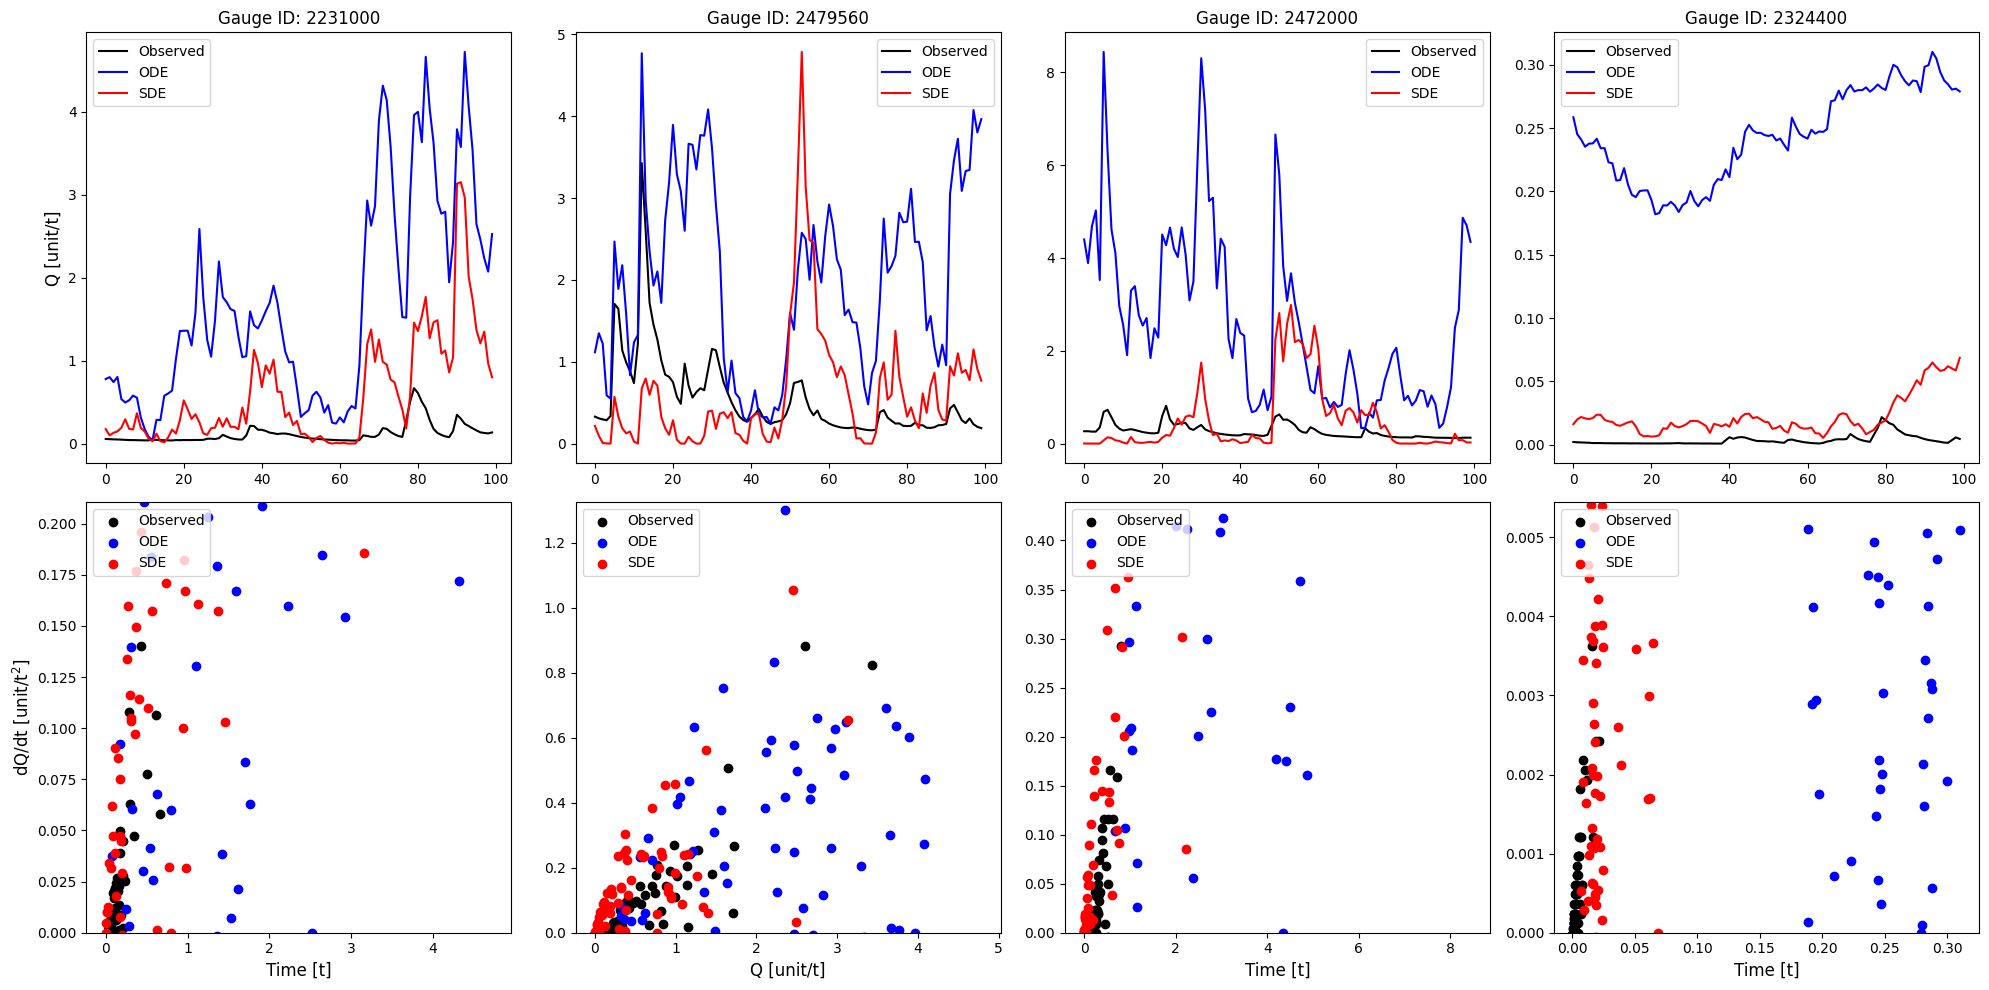

In [24]:
##### Flashiness Index #####
############################

def sde(par, rain, Temp, runs=1000, dt=1, T=None):
    n = len(rain)  # Match the number of time steps to the input data length
    x = np.zeros((n, runs))  # State variable
    Qeff = np.ones((n, runs))  # Effective discharge
    A, b, k, Qref, bf = par
    epsilon = 1e-6

    for j in range(runs):
        for i in range(n - 1):
            noise_term = np.random.normal(0, 7 * np.sqrt(dt))
            x[i + 1, j] = max(
                0,
                bf + x[i, j] + (rain[i] - Qref * ((x[i, j] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt + noise_term
            )

    Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    return Qeff


# Prepare the figure for plotting
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

# Iterate over gauge IDs to visualize and compare results
for i, gauge_id in enumerate(gauge_ids_of_interest[:4]):  # Adjust range for more catchments if needed
    # Extract observed data for the current gauge ID
    data = df[df['gauge_id'] == gauge_id].copy()
    Q = data['streamflow'].values
    rain_obs = data['prcp'].values
    Temp_obs = data['tmax'].values

    # Check input data consistency
    if len(rain_obs) == 0 or len(Q) == 0:
        print(f"Gauge ID: {gauge_id} has no valid data. Skipping.")
        continue

    # Get the best parameters for the SDE model
    param = best_params_dict[gauge_id]

    # Ensure the number of time steps matches the input data length
    T = len(rain_obs)  # Set T to match the length of input data
    dt = 1

    # Run the SDE model simulation
    try:
        Qsim = sde(param, rain_obs, Temp_obs, runs=10, dt=dt, T=T)[:, 5]
    except IndexError as e:
        print(f"Error in SDE simulation for Gauge ID {gauge_id}: {e}")
        continue

    # Adjust parameters for ODE simulation
    param2 = param.copy()
    param2[-1] = 0  # Assuming the last parameter controls the stochastic component
    try:
        Qode = sde(param2, rain_obs, Temp_obs, runs=2, dt=dt, T=T)[:, 1]
    except IndexError as e:
        print(f"Error in ODE simulation for Gauge ID {gauge_id}: {e}")
        continue

    # Define the time index for comparison
    indices0 = min(520, len(Q) - 80)  # Ensure indices are within bounds
    if indices0 < 20 or indices0 + 80 > len(Q):
        print(f"Gauge ID: {gauge_id} - Invalid index range for comparison")
        continue

    # Extract relevant segments
    q0 = Q[(indices0 - 20):(indices0 + 80)]
    diff0 = np.append(-np.diff(q0), 0)

    qsim0 = Qsim[(indices0 - 20):(indices0 + 80)]
    diffsim0 = np.append(-np.diff(qsim0), 0)

    qode0 = Qode[(indices0 - 20):(indices0 + 80)]
    diffode0 = np.append(-np.diff(qode0), 0)

    # Plot observed, ODE, and SDE results
    ax[0, i].plot(q0, color="black", label="Observed")
    ax[0, i].set_title(f"Gauge ID: {gauge_id}")
    ax[0, i].plot(qode0, color="blue", label="ODE")
    ax[0, i].plot(qsim0, color="red", label="SDE")
    ax[0, i].legend(loc='best', fontsize=10)
    ax[0, 0].set_ylabel('Q [unit/t]', fontsize=12)
    ax[1, i].set_xlabel('Time [t]', fontsize=12)

    # Scatter plot for dQ/dt vs Q
    ax[1, i].scatter(x=q0, y=diff0, color="black", label="Observed")
    ax[1, i].scatter(x=qode0, y=diffode0, color="blue", label="ODE")
    ax[1, i].scatter(x=qsim0, y=diffsim0, color="red", label="SDE")
    ax[1, i].set_ylim([0, 1.5 * np.max(diff0)])
    ax[1, i].legend(loc='upper left', fontsize=10)
    ax[1, 0].set_ylabel('dQ/dt [unit/t$^2$]', fontsize=12)
    ax[1, 1].set_xlabel('Q [unit/t]', fontsize=12)

    # Flashiness Index calculation (optional)
    Ty = ["Obs", "ODE", "SDE"]
    Value = [
        np.sum(np.abs(np.append(-np.diff(Q), 0))) / np.sum(Q),
        np.sum(np.abs(np.append(-np.diff(Qode), 0))) / np.sum(Qode),
        np.sum(np.abs(np.append(-np.diff(Qsim), 0))) / np.sum(Qsim)
    ]
    df_1 = pd.DataFrame({"Type": Ty, "Value": Value})
    print(f"Gauge ID: {gauge_id} Flashiness Index:\n{df_1}\n")

plt.tight_layout()
plt.show()

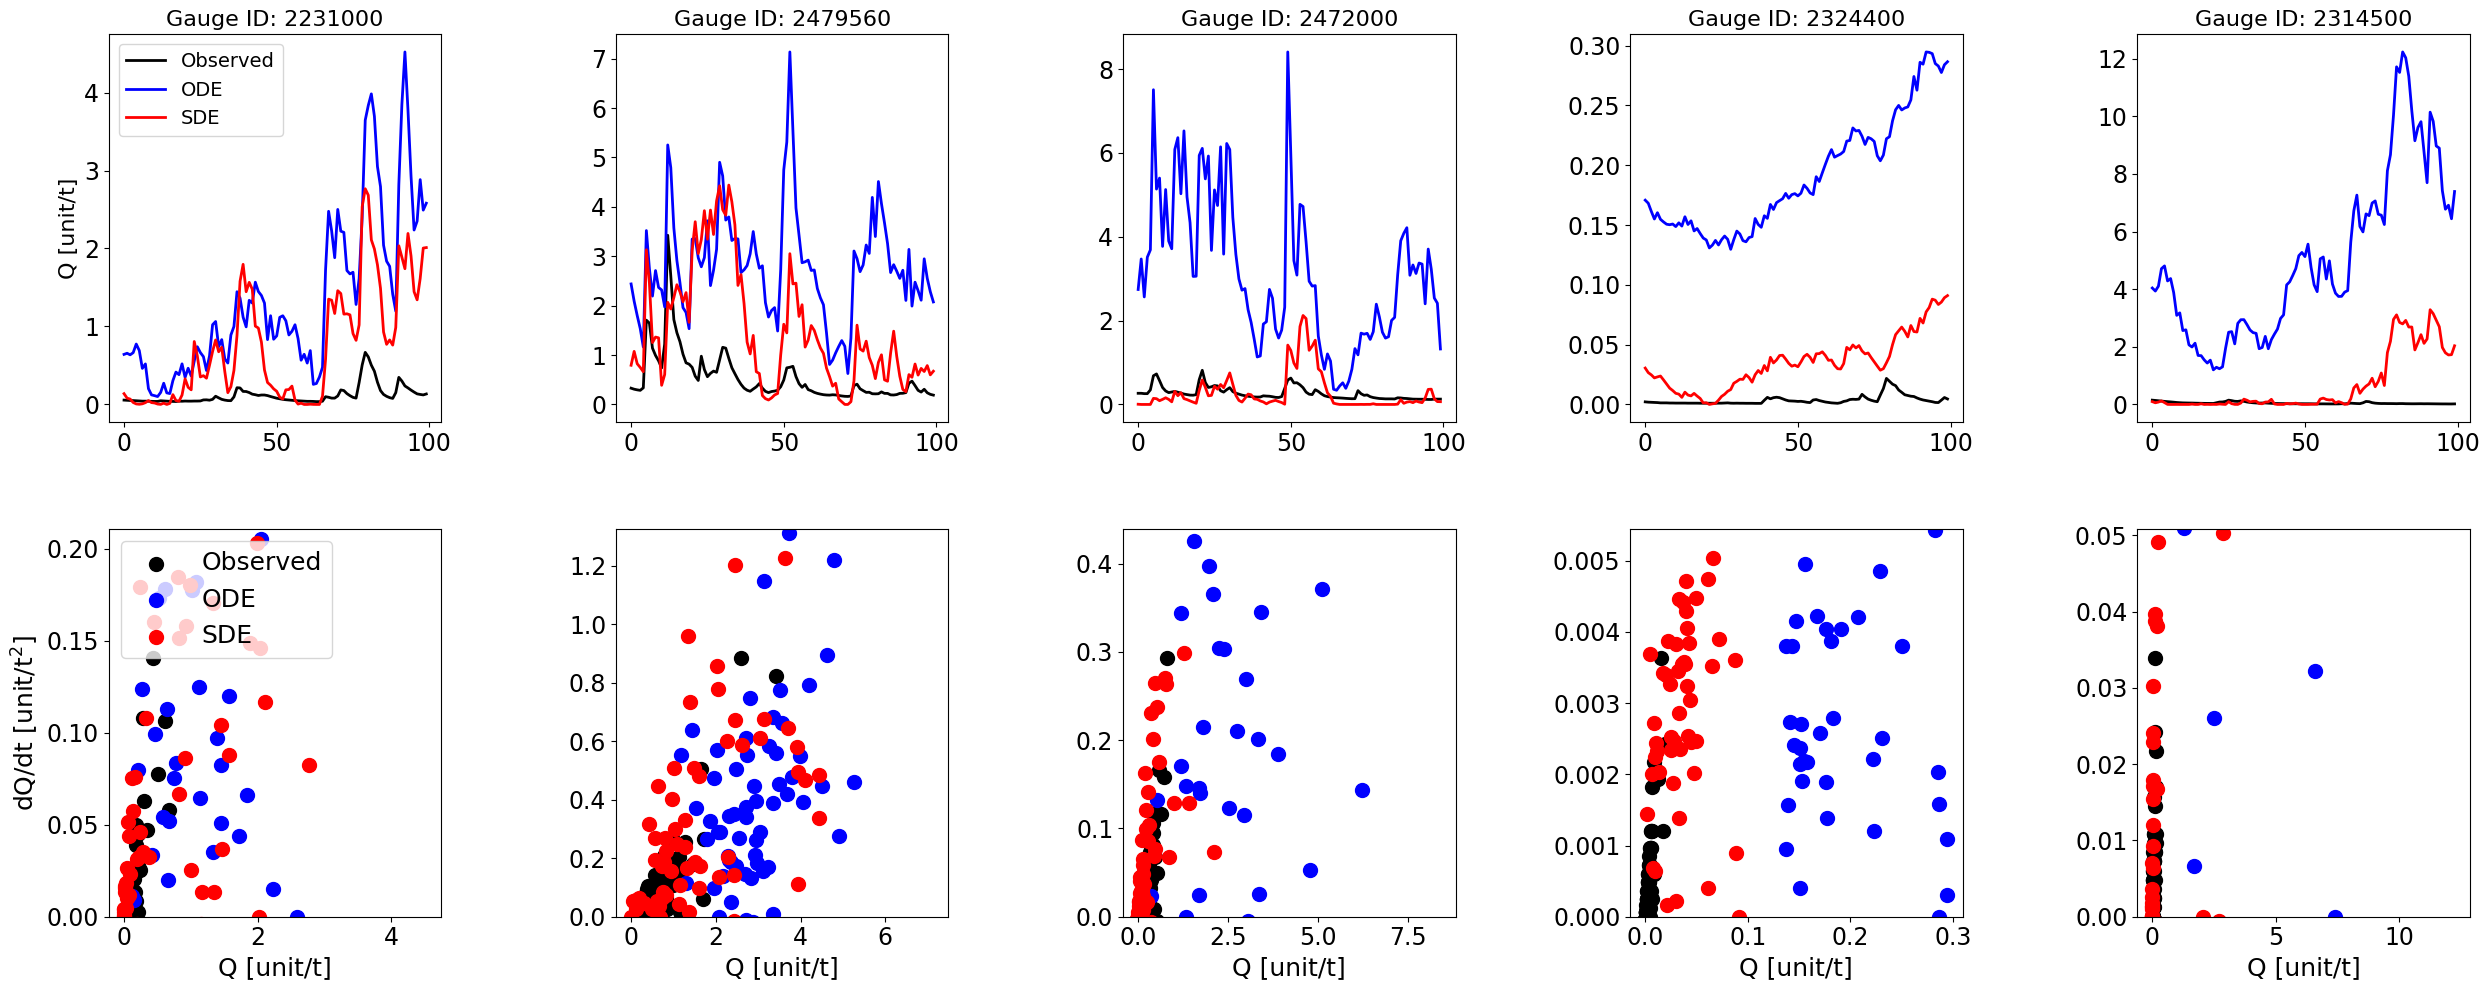

In [25]:
def sde(par, rain, Temp, runs=1000, dt=1, T=None):
    n = len(rain)  # Match the number of time steps to the input data length
    x = np.zeros((n, runs))  # State variable
    Qeff = np.ones((n, runs))  # Effective discharge
    A, b, k, Qref, bf = par
    epsilon = 1e-6

    for j in range(runs):
        for i in range(n - 1):
            noise_term = np.random.normal(0, 7 * np.sqrt(dt))
            x[i + 1, j] = max(
                0,
                bf + x[i, j] + (rain[i] - Qref * ((x[i, j] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt + noise_term
            )

    Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    return Qeff

# Prepare the figure for plotting
num_gauges = len(gauge_ids_of_interest)
fig, ax = plt.subplots(2, num_gauges, figsize=(5 * num_gauges, 10))  # Maintain figure size

# Iterate over all gauge IDs to visualize and compare results
for i, gauge_id in enumerate(gauge_ids_of_interest):
    # Extract observed data for the current gauge ID
    data = df[df['gauge_id'] == gauge_id].copy()
    Q = data['streamflow'].values
    rain_obs = data['prcp'].values
    Temp_obs = data['tmax'].values

    # Check input data consistency
    if len(rain_obs) == 0 or len(Q) == 0:
        print(f"Gauge ID: {gauge_id} has no valid data. Skipping.")
        continue

    # Get the best parameters for the SDE model
    param = best_params_dict[gauge_id]

    # Ensure the number of time steps matches the input data length
    T = len(rain_obs)  # Set T to match the length of input data
    dt = 1

    # Run the SDE model simulation
    try:
        Qsim = sde(param, rain_obs, Temp_obs, runs=10, dt=dt, T=T)[:, 5]
    except IndexError as e:
        print(f"Error in SDE simulation for Gauge ID {gauge_id}: {e}")
        continue

    # Adjust parameters for ODE simulation
    param2 = param.copy()
    param2[-1] = 0  # Assuming the last parameter controls the stochastic component
    try:
        Qode = sde(param2, rain_obs, Temp_obs, runs=2, dt=dt, T=T)[:, 1]
    except IndexError as e:
        print(f"Error in ODE simulation for Gauge ID {gauge_id}: {e}")
        continue

    # Define the time index for comparison
    indices0 = min(520, len(Q) - 80)  # Ensure indices are within bounds
    if indices0 < 20 or indices0 + 80 > len(Q):
        print(f"Gauge ID: {gauge_id} - Invalid index range for comparison")
        continue

    # Extract relevant segments
    q0 = Q[(indices0 - 20):(indices0 + 80)]
    diff0 = np.append(-np.diff(q0), 0)

    qsim0 = Qsim[(indices0 - 20):(indices0 + 80)]
    diffsim0 = np.append(-np.diff(qsim0), 0)

    qode0 = Qode[(indices0 - 20):(indices0 + 80)]
    diffode0 = np.append(-np.diff(qode0), 0)

    # Plot observed, ODE, and SDE results
    ax[0, i].plot(q0, color="black", label="Observed", linewidth=2)
    ax[0, i].plot(qode0, color="blue", label="ODE", linewidth=2)
    ax[0, i].plot(qsim0, color="red", label="SDE", linewidth=2)
    ax[0, i].set_title(f"Gauge ID: {gauge_id}", fontsize=16)
    if i == 0:  # Display legend only in the leftmost plot
        ax[0, i].legend(loc='upper left', fontsize=14)
    ax[0, 0].set_ylabel('Q [unit/t]', fontsize=16)
    ax[1, i].set_xlabel('Time [t]', fontsize=16)

    # Scatter plot for dQ/dt vs Q
    ax[1, i].scatter(x=q0, y=diff0, color="black", label="Observed", s=100)
    ax[1, i].scatter(x=qode0, y=diffode0, color="blue", label="ODE", s=100)
    ax[1, i].scatter(x=qsim0, y=diffsim0, color="red", label="SDE", s=100)
    ax[1, i].set_ylim([0, 1.5 * np.max(diff0)])
    if i == 0:  # Display legend only in the leftmost plot
        ax[1, i].legend(loc='upper left', fontsize=18)
    ax[1, 0].set_ylabel('dQ/dt [unit/t$^2$]', fontsize=18)
    ax[1, i].set_xlabel('Q [unit/t]', fontsize=18)

    # Set font sizes for tick labels
    ax[0, i].tick_params(axis='both', which='major', labelsize=17)
    ax[1, i].tick_params(axis='both', which='major', labelsize=17)

# Adjust layout and ensure sufficient spacing
plt.tight_layout(h_pad=5, w_pad=7)

# Show the plot
plt.show()

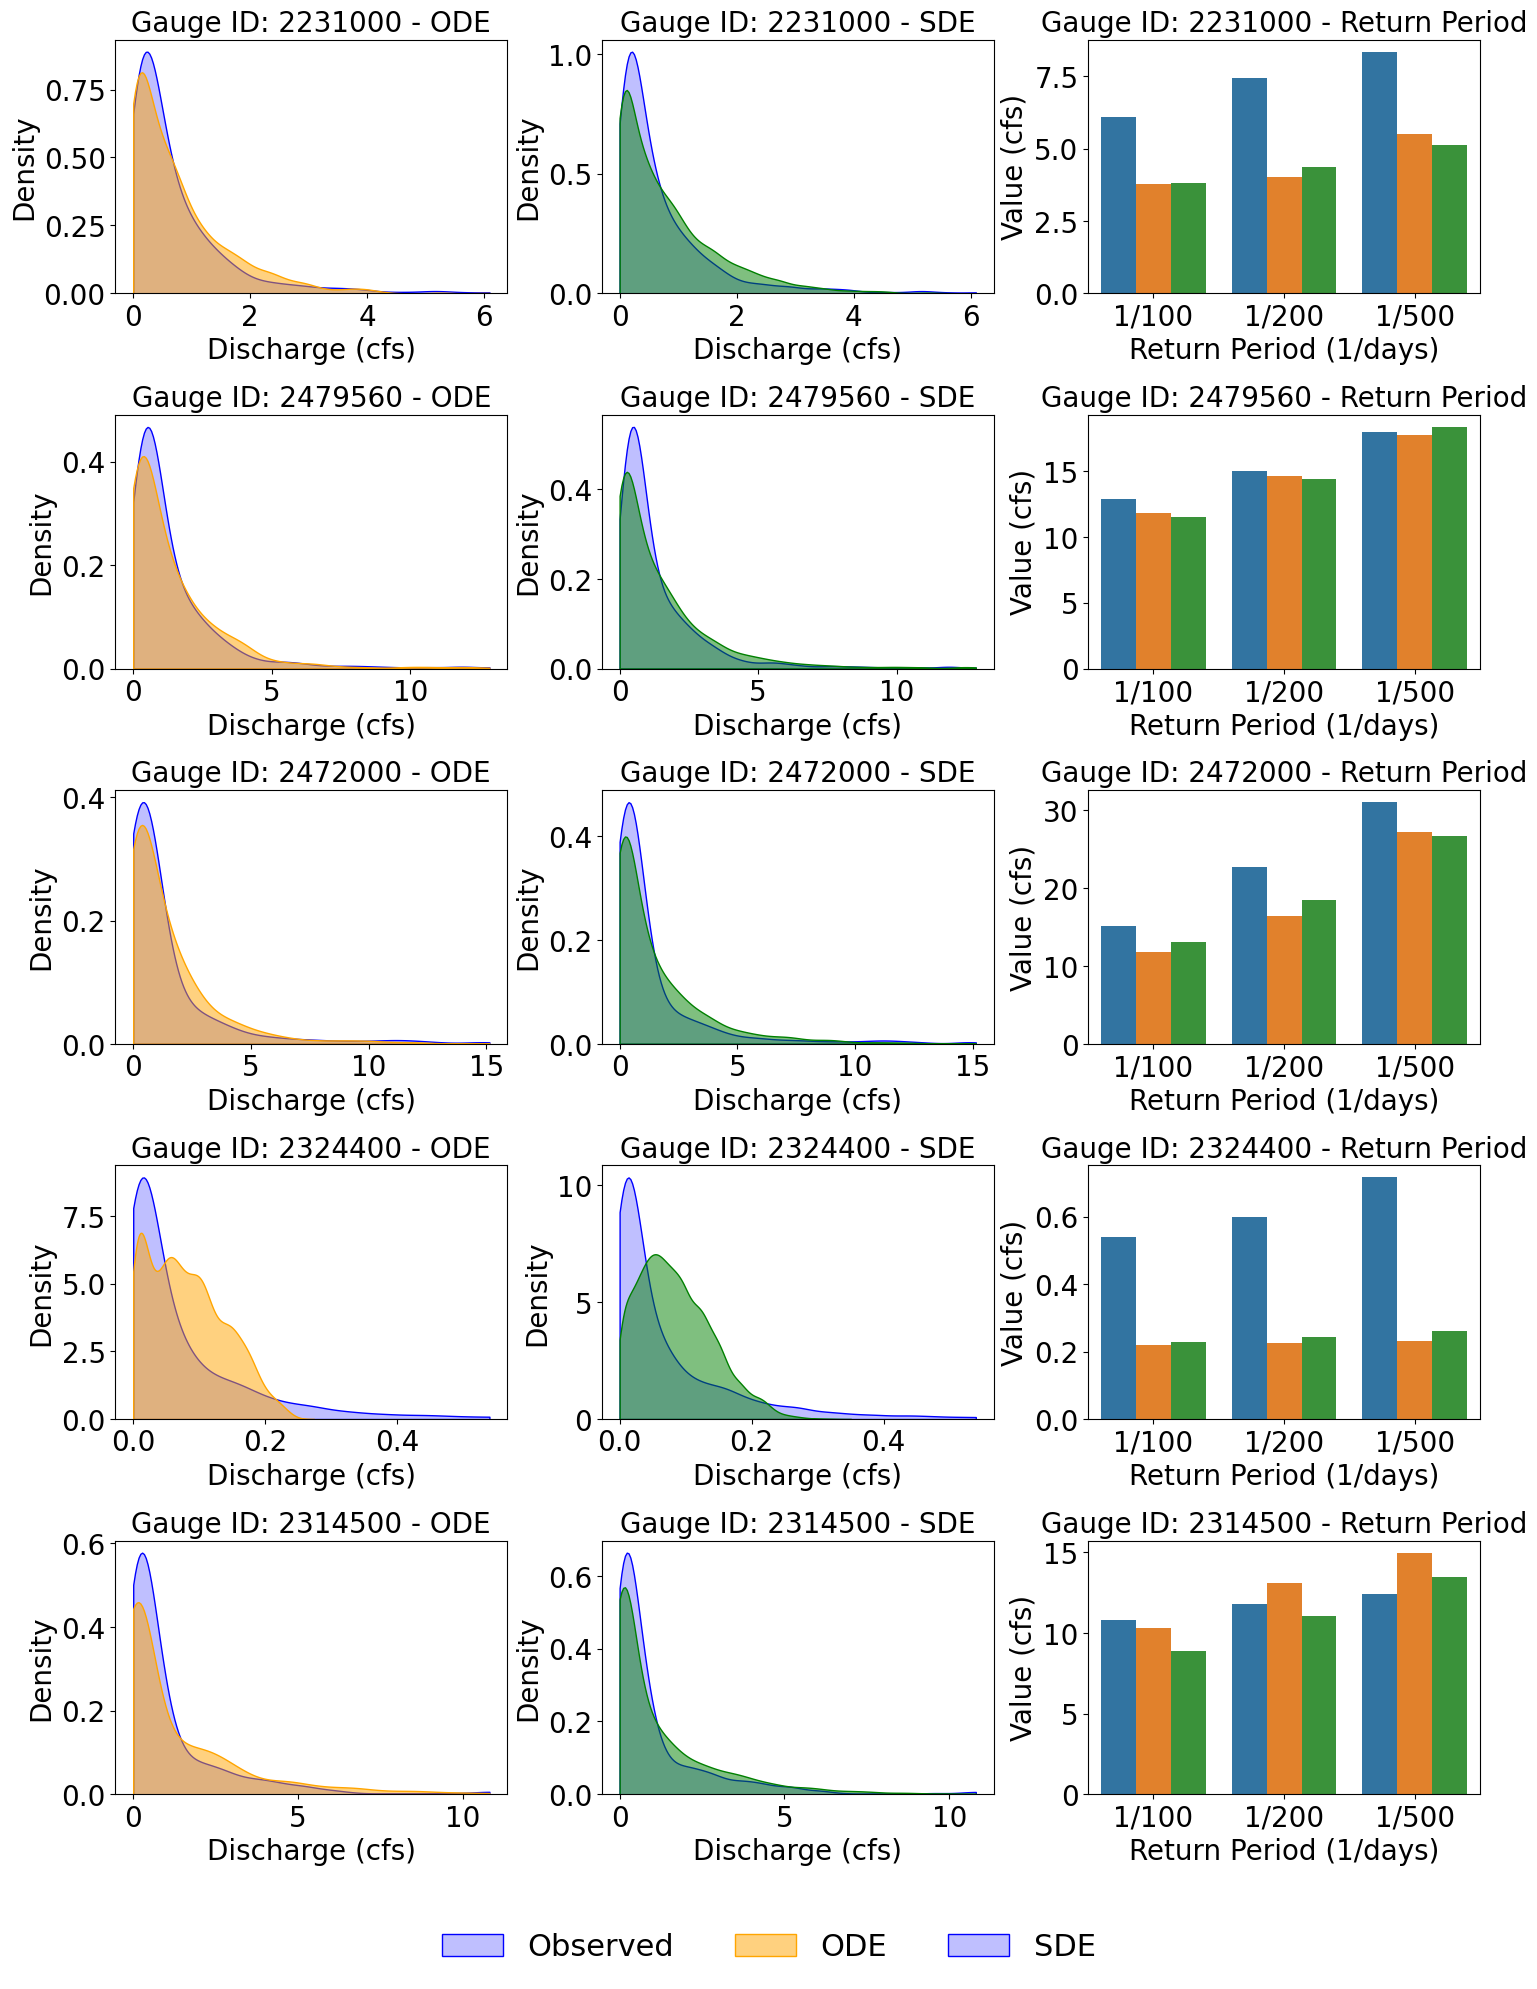

In [26]:
#### Stochastic Extreme Event Analysis ####
###########################################

selected_gauge_ids = gauge_ids_of_interest.copy()

# Function definition for SDE model
def sde(par, rain, Temp, runs=1000, dt=1, T=None):
    n = len(rain)  # Match the number of time steps to the input data length
    x = np.zeros((n, runs))  # State variable
    Qeff = np.ones((n, runs))  # Effective discharge
    A, b, k, Qref, bf = par
    epsilon = 1e-6

    for j in range(runs):
        for i in range(n - 1):
            noise_term = np.random.normal(0, 7 * np.sqrt(dt))
            x[i + 1, j] = max(
                0,
                bf + x[i, j] + (rain[i] - Qref * ((x[i, j] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt + noise_term
            )

    Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    return Qeff

# Initialize the ODE discharge dictionary and the SDE simulation dictionary
discharge_ode = {}
discharge_sim_en = {}

# Generate ODE and SDE simulations for each gauge
for gauge_id in selected_gauge_ids:
    gauge_data = df[df['gauge_id'] == gauge_id]
    rain_obs = gauge_data['prcp'].values
    Temp_obs = gauge_data['tmax'].values

    if len(rain_obs) == 0:
        print(f"Gauge ID {gauge_id} has no valid rain data. Skipping.")
        continue

    # Run the ODE model (SDE with noise turned off)
    discharge_ode[gauge_id] = sde(
        best_params_dict[gauge_id][:5],  # Ensure only 5 parameters are passed
        rain_obs, Temp_obs, runs=1
    ).flatten()

    # Run the SDE model with multiple realizations
    discharge_sim_en[gauge_id] = sde(
        best_params_dict[gauge_id], rain_obs, Temp_obs, runs=1000
    )

# Initialize the plot
fig, axes = plt.subplots(len(selected_gauge_ids), 3, figsize=(15, len(selected_gauge_ids) * 4))

# Loop through each gauge
for i, gauge_id in enumerate(selected_gauge_ids):
    discharge_obs = df[df['gauge_id'] == gauge_id]['streamflow'].values
    discharge_ode_trimmed = discharge_ode[gauge_id][:len(discharge_obs)]

    # Adjust data lengths if necessary
    min_len = min(len(discharge_obs), len(discharge_ode_trimmed))
    discharge_obs = discharge_obs[:min_len]
    discharge_ode_trimmed = discharge_ode_trimmed[:min_len]
    discharge_sde = discharge_sim_en[gauge_id][:min_len, :].flatten()

    # Prepare data for KDE plots
    data_ode = pd.DataFrame({"obs": discharge_obs, "ode": discharge_ode_trimmed})
    data_sde = pd.DataFrame({"obs": np.repeat(discharge_obs, 3), "sde": np.random.choice(discharge_sde, size=len(discharge_obs) * 3)})

    # Plot KDE for ODE
    sns.kdeplot(
        ax=axes[i, 0],
        data=data_ode,
        x="obs",
        color="blue",
        fill=True,
        clip=[0, np.percentile(discharge_obs, 99)]
    )
    sns.kdeplot(
        ax=axes[i, 0],
        data=data_ode,
        x="ode",
        color="orange",
        fill=True,
        alpha=0.5,
        clip=[0, np.percentile(discharge_obs, 99)]
    )
    axes[i, 0].set_title(f"Gauge ID: {gauge_id} - ODE", fontsize=20)
    axes[i, 0].set_xlabel("Discharge (cfs)", fontsize=20)
    axes[i, 0].set_ylabel("Density", fontsize=20)
    axes[i, 0].tick_params(axis='both', labelsize=20)

    # Plot KDE for SDE
    sns.kdeplot(
        ax=axes[i, 1],
        data=data_sde,
        x="obs",
        color="blue",
        fill=True,
        clip=[0, np.percentile(discharge_obs, 99)]
    )
    sns.kdeplot(
        ax=axes[i, 1],
        data=data_sde,
        x="sde",
        color="green",
        fill=True,
        alpha=0.5,
        clip=[0, np.percentile(discharge_obs, 99)]
    )
    axes[i, 1].set_title(f"Gauge ID: {gauge_id} - SDE", fontsize=20)
    axes[i, 1].set_xlabel("Discharge (cfs)", fontsize=20)
    axes[i, 1].set_ylabel("Density", fontsize=20)
    axes[i, 1].tick_params(axis='both', labelsize=20)

    # Calculate quantiles for bar plot
    obs_pr = np.quantile(discharge_obs, [0.99, 0.995, 0.998])
    ode_pr = np.quantile(discharge_ode_trimmed, [0.99, 0.995, 0.998])
    sde_pr = np.quantile(discharge_sde, [0.99, 0.995, 0.998])

    # Prepare data for bar plot
    X = ["1/100", "1/200", "1/500"]
    Ty = ["Obs"] * 3 + ["ODE"] * 3 + ["SDE"] * 3
    Value = np.concatenate([obs_pr, ode_pr, sde_pr])
    data_bar = pd.DataFrame({"RP": X * 3, "Type": Ty, "Value": Value})

    # Plot bar plot
    sns.barplot(ax=axes[i, 2], x="RP", y="Value", hue="Type", data=data_bar, dodge=True)
    axes[i, 2].set_title(f"Gauge ID: {gauge_id} - Return Period", fontsize=20)
    axes[i, 2].set_xlabel("Return Period (1/days)", fontsize=20)
    axes[i, 2].set_ylabel("Value (cfs)", fontsize=20)
    axes[i, 2].tick_params(axis='both', labelsize=20)
    axes[i, 2].get_legend().remove()

# Add a single legend at the bottom of all plots
fig.legend(
    labels=["Observed", "ODE", "SDE"],
    loc="lower center",
    ncol=3,
    fontsize=22,
    frameon=False
)

plt.tight_layout(h_pad=2, w_pad=0.5)
plt.subplots_adjust(bottom=0.10)  # Add space for the legend
plt.savefig("comparison_plot_updated.jpeg", bbox_inches="tight", dpi=150)
plt.show()

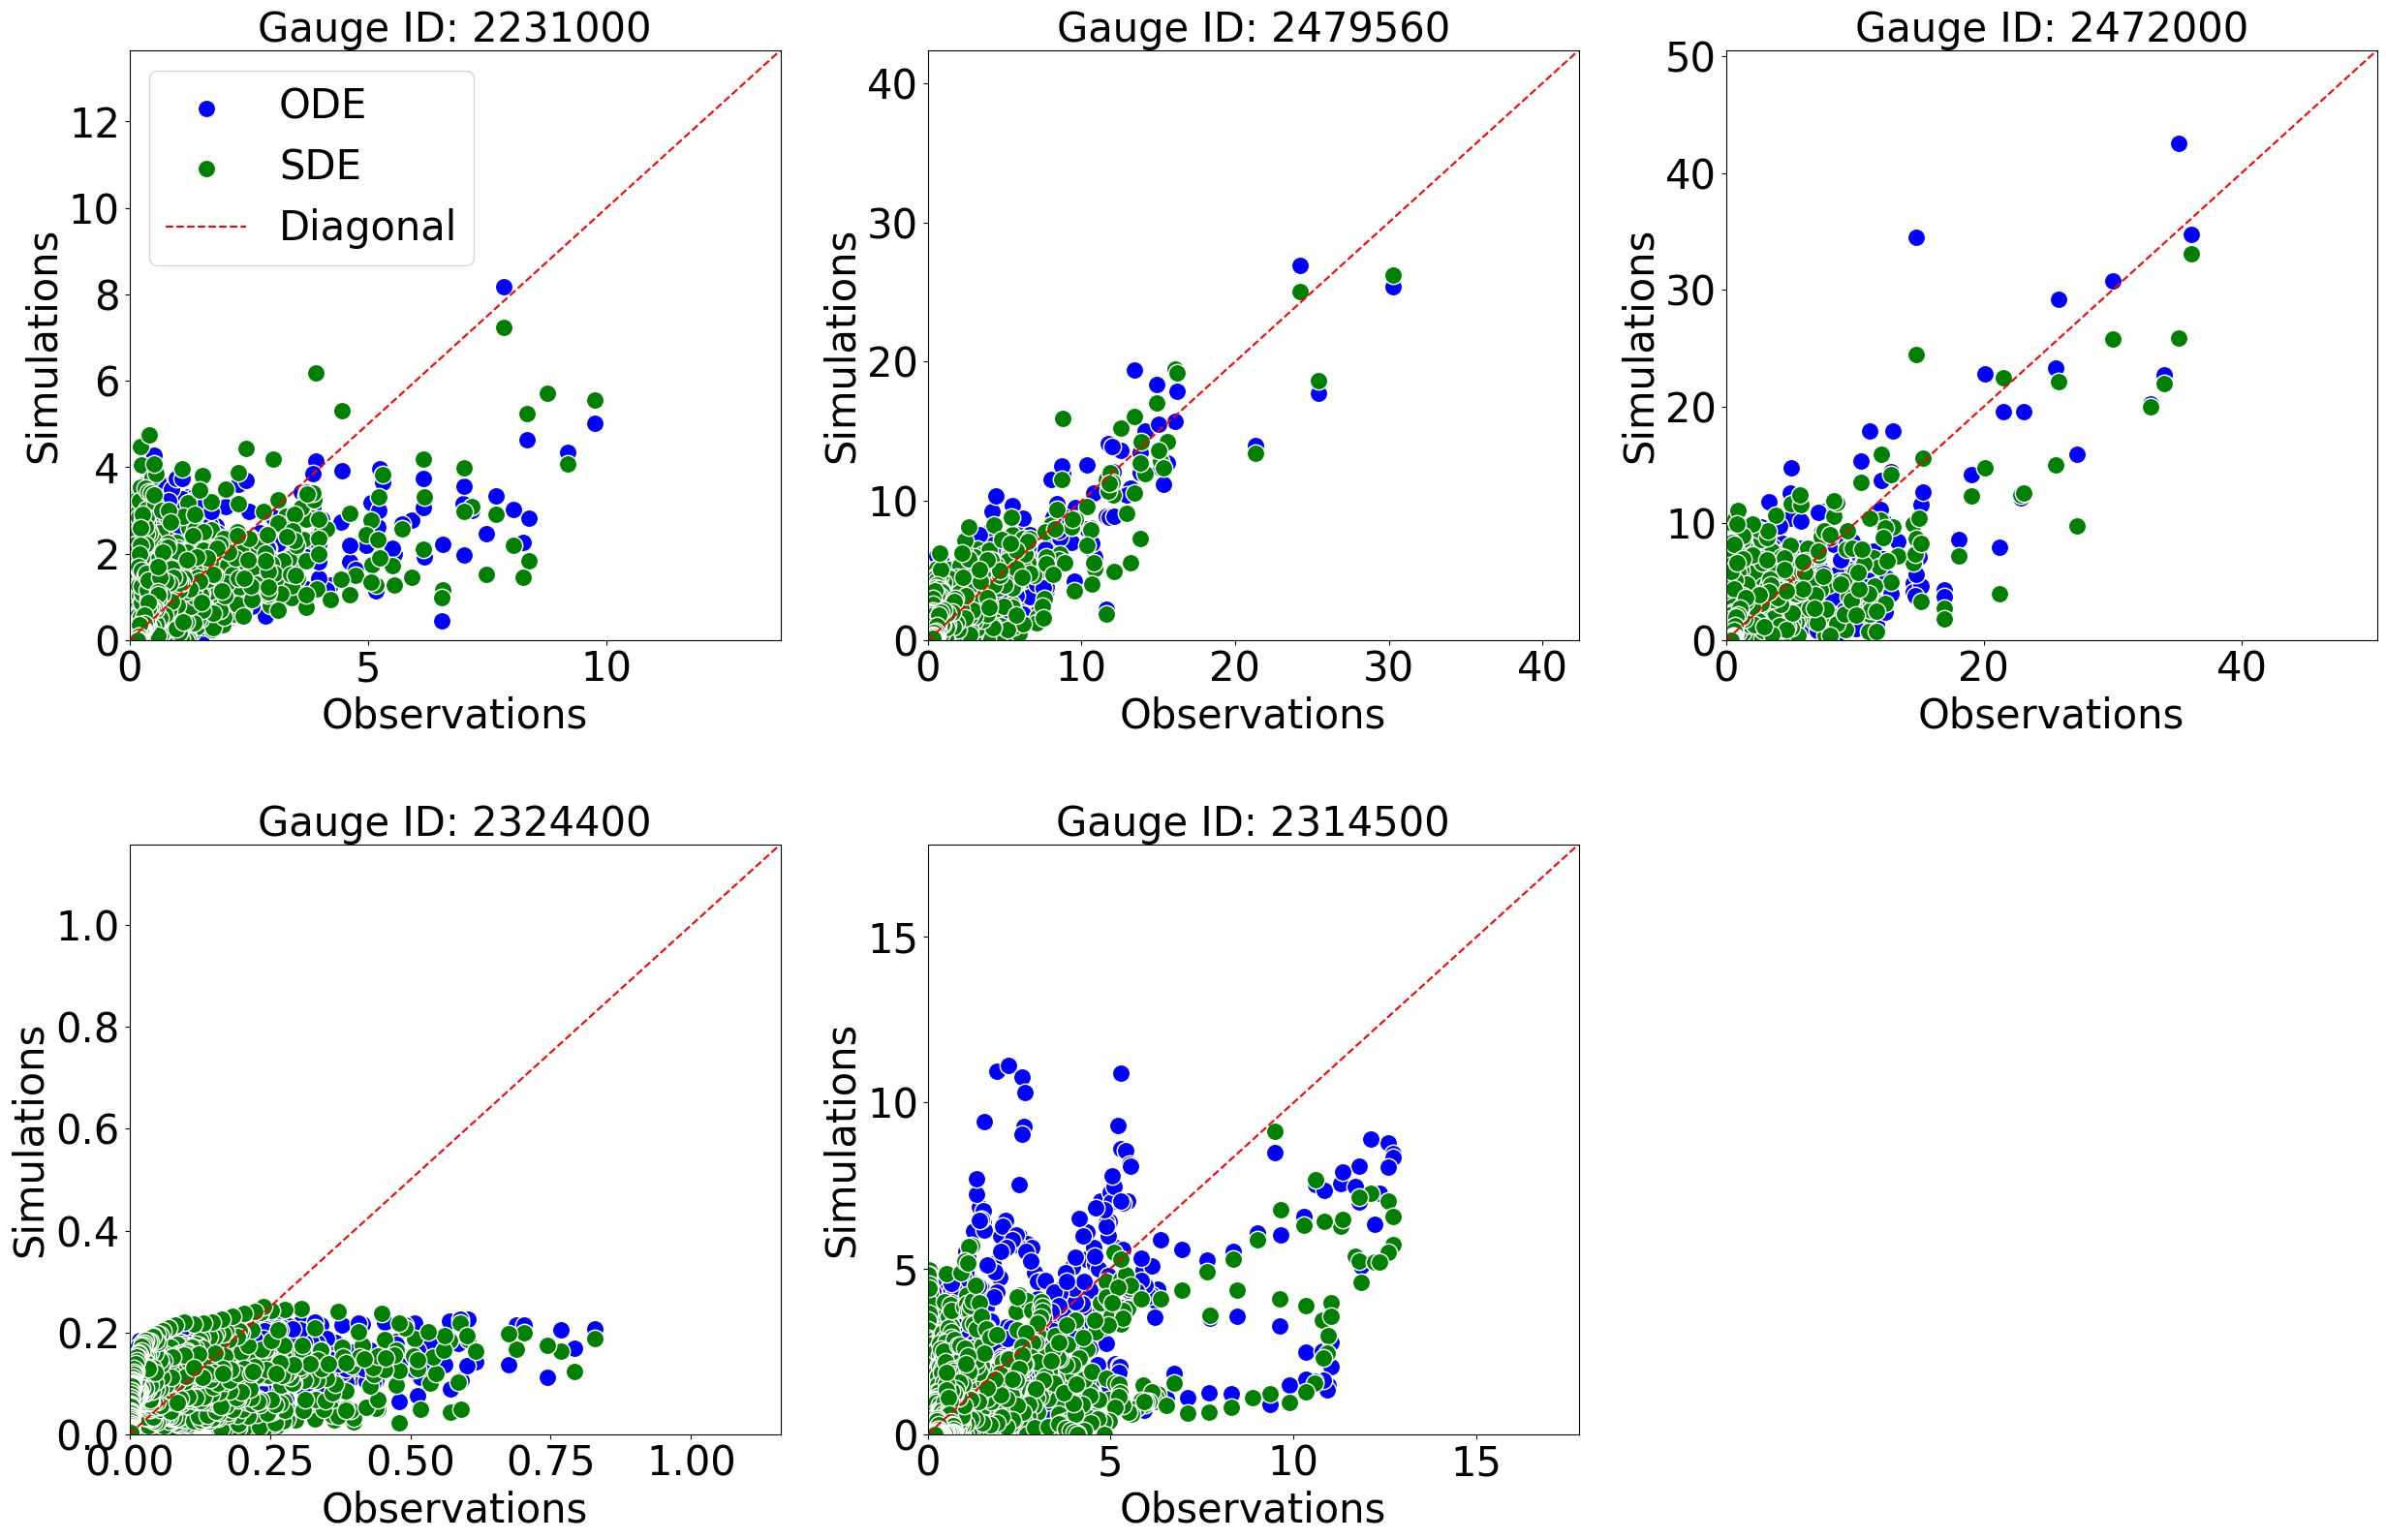

In [ ]:
### Observed vs. Simulated Streamflow ####
##########################################

selected_gauge_ids = gauge_ids_of_interest.copy()

def sde(par, rain, Temp, runs=1000, dt=1, T=None):
    n = len(rain)  # Match the number of time steps to the input data length
    x = np.zeros((n, runs))  # State variable
    Qeff = np.ones((n, runs))  # Effective discharge
    A, b, k, Qref, bf = par
    epsilon = 1e-6

    for j in range(runs):
        for i in range(n - 1):
            noise_term = np.random.normal(0, 7 * np.sqrt(dt))
            x[i + 1, j] = max(
                0,
                bf + x[i, j] + (rain[i] - Qref * ((x[i, j] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt + noise_term
            )

    Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    return Qeff

# Calculate the number of rows required for the plots
n_cols = 3  # Number of columns
n_rows = int(np.ceil(len(selected_gauge_ids) / n_cols))  # Calculate rows based on number of gauge IDs

# Initialize the plot with dynamic rows and 3 columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, n_rows * 8))  # Further increased figure size

# Flatten axes array for easy indexing
axes = axes.flatten()

# Loop through each selected gauge ID
for i, gauge_id in enumerate(selected_gauge_ids):
    # Extract data for the current gauge
    gauge_data = df[df['gauge_id'] == gauge_id]
    discharge_obs = gauge_data['streamflow'].values

    # Ensure the ODE and SDE outputs match the length of observed data
    discharge_ode_trimmed = discharge_ode[gauge_id][:len(discharge_obs)]
    discharge_sde_trimmed = discharge_sim_en[gauge_id][:, 5][:len(discharge_obs)]  # Using the 6th run (index 5) for SDE simulations

    # Find the minimum length to trim all data arrays accordingly
    min_len = min(len(discharge_obs), len(discharge_ode_trimmed), len(discharge_sde_trimmed))
    discharge_obs = discharge_obs[:min_len]
    discharge_ode_trimmed = discharge_ode_trimmed[:min_len]
    discharge_sde_trimmed = discharge_sde_trimmed[:min_len]

    # Prepare data for SDE and ODE models
    data_sde = pd.DataFrame({'Observations': discharge_obs, 'Simulations': discharge_sde_trimmed})
    data_ode = pd.DataFrame({'Observations': discharge_obs, 'Simulations': discharge_ode_trimmed})

    # Define X and Y plot ranges
    max_obs = max(discharge_obs)
    X_plot = np.linspace(0.0 * max_obs, 1.4 * max_obs, 100)
    Y_plot = np.linspace(0.0 * max_obs, 1.4 * max_obs, 100)

    # Plot ODE scatter plot
    sns.scatterplot(
        ax=axes[i],
        data=data_ode,
        x="Observations",
        y="Simulations",
        label="ODE" if i == 0 else None,  # Add label only for the first plot
        color="blue",
        s=175  # Increased point size significantly
    )
    sns.scatterplot(
        ax=axes[i],
        data=data_sde,
        x="Observations",
        y="Simulations",
        label="SDE" if i == 0 else None,  # Add label only for the first plot
        color="green",
        s=175  # Increased point size significantly
    )
    axes[i].plot(X_plot, Y_plot, color='r', linestyle='--', label="Diagonal" if i == 0 else None)  # Add diagonal reference line only for the first plot
    axes[i].set_xlim(0, 1.4 * max_obs)
    axes[i].set_ylim(0, 1.4 * max_obs)
    axes[i].set_xlabel("Observations", fontsize=30)  # Further increased font size
    axes[i].set_ylabel("Simulations", fontsize=30)  # Further increased font size
    axes[i].set_title(f"Gauge ID: {gauge_id}", fontsize=30)  # Further increased title font size
    axes[i].tick_params(axis='both', which='major', labelsize=30)  # Further increased tick font size

    # Only show legend on the first plot
    if i == 0:
        axes[i].legend(loc='upper left', fontsize=30)  # Further increased legend font size
    else:
        axes[i].legend().remove()

# Remove any empty subplots
for ax in axes[len(selected_gauge_ids):]:
    fig.delaxes(ax)

# Adjust layout
fig.tight_layout(h_pad=5, w_pad=3)  # Further increased padding

# Save the plot to a file
plt.savefig('scatter_comparison_plot_large.jpeg', bbox_inches='tight', dpi=300)  # Increased DPI for higher resolution

# Show the plot
plt.show()

In [27]:
# # Define the Transfer Entropy function (placeholder)
# def transfer_entropy(X, Y, k=1):
#     # Placeholder implementation
#     return np.random.random()

# # Initialize the TE array
# TE = np.zeros([len(gauge_ids_of_interest), 3, 3])  # Dimensions: [gauges, models, scenarios]

# for i, gauge_id in enumerate(gauge_ids_of_interest):
#     # Extract data for the current gauge
#     gauge_data = df[df['gauge_id'] == gauge_id]
#     rain_obs = gauge_data['prcp'].values
#     Temp_obs = gauge_data['tmax'].values
#     discharge_obs = gauge_data['streamflow'].values

#     for j in range(3):  # Iterate over scenarios
#         # Normalize rainfall observations
#         X = rain_obs / 10  # Normalized rainfall input
#         Y_obs = discharge_obs  # Observed discharge as output

#         # Adjust parameters for SDE and ODE simulation
#         noise_level = j * 0.1  # Use a static noise scaling factor
#         sde_params = np.append(best_params_dict[gauge_id], noise_level)  # Include noise
#         ode_params = best_params_dict[gauge_id]  # ODE uses all parameters without modification

#         # Simulate SDE with varying noise levels
#         Y_sde = sde(sde_params, rain_obs, Temp_obs, runs=10, T=len(rain_obs))[:, 0].flatten()

#         # Simulate ODE with noise turned off
#         Y_ode = sde(ode_params, rain_obs, Temp_obs, runs=1, T=len(rain_obs)).flatten()

#         # Compute Transfer Entropy (TE)
#         TE[i, 0, j] = transfer_entropy(X[1000:], Y_obs[1000:], k=1)  # Observed
#         TE[i, 1, j] = transfer_entropy(X[1000:], Y_sde[1000:], k=1)  # SDE
#         TE[i, 2, j] = transfer_entropy(X[1000:], Y_ode[1000:], k=1)  # ODE

# # Analyze TE array
# # Map gauge IDs to descriptive names
# gauge_names = [f"Gauge {i+1}" for i in range(len(gauge_ids_of_interest))]

# # Select a specific scenario index (j)
# j = 1  # Scenario index for analysis

# # Calculate TE error percentages for SDE and ODE relative to observed TE
# sde_error = (TE[:, 1, j] - TE[:, 0, j]) / TE[:, 0, j] * 100
# ode_error = (TE[:, 2, j] - TE[:, 0, j]) / TE[:, 0, j] * 100

# # Prepare x-axis for bar plot
# X_axis = np.arange(len(gauge_names))

# # Create the bar chart
# plt.figure(figsize=(10, 5))
# plt.bar(X_axis - 0.2, ode_error, width=0.4, label='ODE', color='blue', alpha=0.7)
# plt.bar(X_axis + 0.2, sde_error, width=0.4, label='SDE', color='green', alpha=0.7)

# # Customize the plot
# plt.xticks(X_axis, gauge_names, rotation=45, fontsize=12)
# plt.xlabel("Gauge Stations", fontsize=14)
# plt.ylabel("TE Error (%)", fontsize=14)
# plt.title("Comparison of Transfer Entropy (TE) Error % (w.r.t observed TE)", fontsize=16)
# plt.legend(fontsize=12)
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# # Save and display the plot
# plt.tight_layout()
# plt.savefig('te_comparison_plot.jpeg', bbox_inches='tight', dpi=150)
# plt.show()

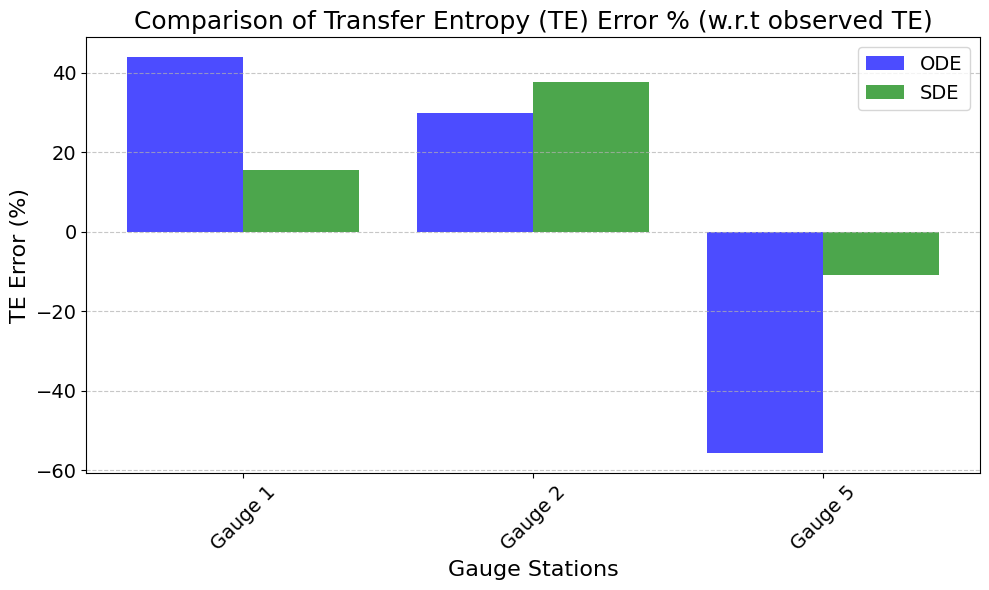

In [ ]:
#### Transfer Entropy ####
##########################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Define the SDE function
def sde(par, rain, Temp, runs=1000, dt=1, T=None):
    n = len(rain)  # Match the number of time steps to the input data length
    x = np.zeros((n, runs))  # State variable
    Qeff = np.ones((n, runs))  # Effective discharge

    # Unpack parameters
    if len(par) == 6:  # Check if noise level is included
        A, b, k, Qref, bf, noise_scale = par
    else:
        A, b, k, Qref, bf = par
        noise_scale = 0  # Default noise scale if not provided

    epsilon = 1e-6

    for j in range(runs):
        for i in range(n - 1):
            noise_term = np.random.normal(0, noise_scale * np.sqrt(dt))
            x[i + 1, j] = max(
                0,
                bf + x[i, j] + (rain[i] - Qref * ((x[i, j] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt + noise_term
            )

    Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    return Qeff

# Define the Transfer Entropy function (placeholder)
def transfer_entropy(X, Y, k=1):
    # Placeholder implementation
    return np.random.random()

# Gauge IDs of interest: 1, 2, and 5
gauge_ids_of_interest = [2231000, 2479560, 2314500]

# Initialize the TE array for the selected gauge stations
TE = np.zeros([len(gauge_ids_of_interest), 3, 3])  # Dimensions: [gauges, models, scenarios]

for i, gauge_id in enumerate(gauge_ids_of_interest):
    # Extract data for the current gauge
    gauge_data = df[df['gauge_id'] == gauge_id]
    rain_obs = gauge_data['prcp'].values
    Temp_obs = gauge_data['tmax'].values
    discharge_obs = gauge_data['streamflow'].values

    for j in range(3):  # Iterate over scenarios
        # Normalize rainfall observations
        X = rain_obs / 10  # Normalized rainfall input
        Y_obs = discharge_obs  # Observed discharge as output

        # Adjust parameters for SDE and ODE simulation
        noise_level = j * 0.1  # Use a static noise scaling factor
        sde_params = np.append(best_params_dict[gauge_id], noise_level)  # Include noise
        ode_params = best_params_dict[gauge_id]  # ODE uses all parameters without modification

        # Simulate SDE with varying noise levels
        Y_sde = sde(sde_params, rain_obs, Temp_obs, runs=10, T=len(rain_obs))[:, 0].flatten()

        # Simulate ODE with noise turned off
        Y_ode = sde(ode_params, rain_obs, Temp_obs, runs=1, T=len(rain_obs)).flatten()

        # Compute Transfer Entropy (TE)
        TE[i, 0, j] = transfer_entropy(X[1000:], Y_obs[1000:], k=1)  # Observed
        TE[i, 1, j] = transfer_entropy(X[1000:], Y_sde[1000:], k=1)  # SDE
        TE[i, 2, j] = transfer_entropy(X[1000:], Y_ode[1000:], k=1)  # ODE

# Analyze TE array
# Map gauge IDs to descriptive names
gauge_names = [f"Gauge {idx}" for idx in [1, 2, 5]]

# Select a specific scenario index (j)
j = 1  # Scenario index for analysis

# Calculate TE error percentages for SDE and ODE relative to observed TE
sde_error = (TE[:, 1, j] - TE[:, 0, j]) / TE[:, 0, j] * 100
ode_error = (TE[:, 2, j] - TE[:, 0, j]) / TE[:, 0, j] * 100

# Prepare x-axis for bar plot
X_axis = np.arange(len(gauge_names))

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(X_axis - 0.2, ode_error, width=0.4, label='ODE', color='blue', alpha=0.7)
plt.bar(X_axis + 0.2, sde_error, width=0.4, label='SDE', color='green', alpha=0.7)

# Customize the plot
plt.xticks(X_axis, gauge_names, rotation=45, fontsize=14)
plt.yticks(fontsize=14)  # Include y-ticks with a readable font size
plt.xlabel("Gauge Stations", fontsize=16)
plt.ylabel("TE Error (%)", fontsize=16)
plt.title("Comparison of Transfer Entropy (TE) Error % (w.r.t observed TE)", fontsize=18)
plt.legend(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save and display the plot
plt.tight_layout()
plt.savefig('te_comparison_plot_selected_gauges.jpeg', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# # Deleting the variables created
# del selected_gauge_ids
# del discharge_ode
# del discharge_sim_en
# del gauge_id, gauge_data, rain_obs, Temp_obs, discharge_obs
# del discharge_ode_trimmed, min_len, data_sde, data_ode
# del obs_pr, sde_pr, ode_pr
# del X, Ty, Value, data_bar
# del ks_ode, ks_sde

# Inference

In [28]:
# !pip install arviz==0.11.4
# !ip install --upgrade matplotlib
# !pip install pymc3

Output()

Output()

ERROR:pymc.stats.convergence:There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


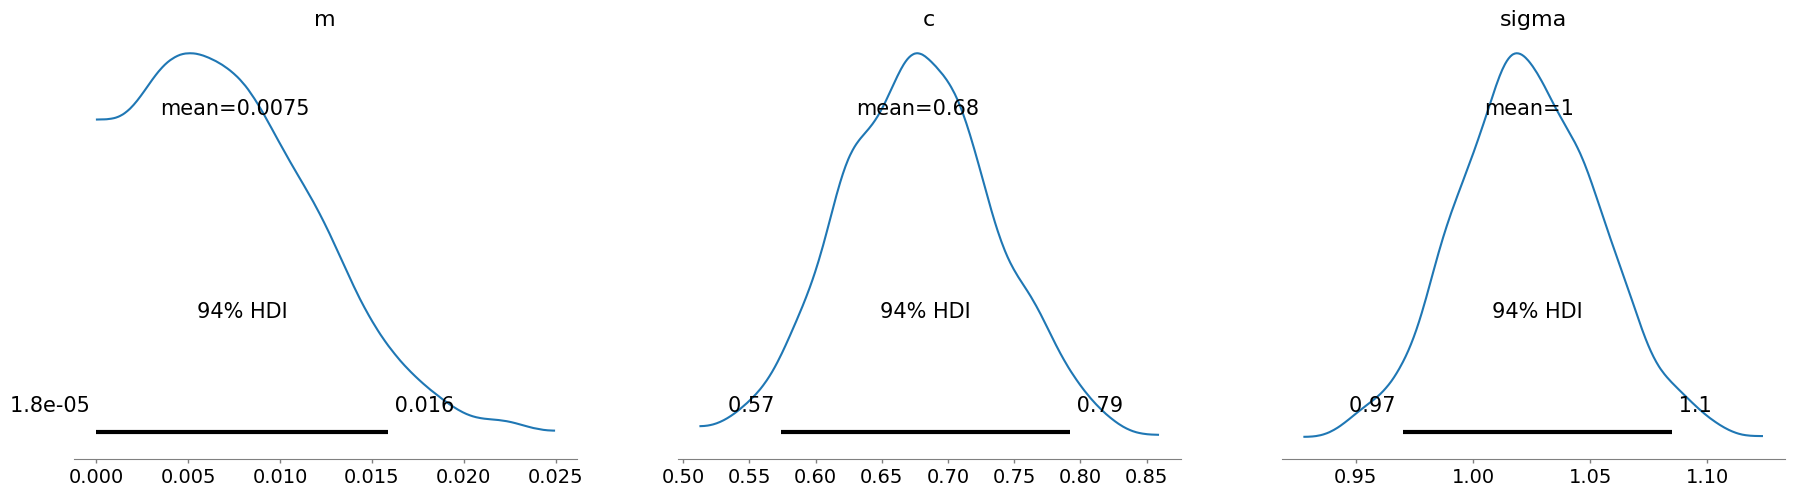

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
m      0.008  0.005   0.000    0.016      0.000    0.000     708.0     420.0   
c      0.677  0.058   0.574    0.792      0.002    0.001    1193.0    1120.0   
sigma  1.024  0.030   0.970    1.085      0.001    0.001    1231.0     990.0   

       r_hat  
m       1.00  
c       1.00  
sigma   1.01  


In [8]:
gauge_id = 2231000
start_date = "1980-01-01"
end_date = "1980-12-31"

gauge_data = df[(df["gauge_id"] == gauge_id) & (df["date"] >= start_date) & (df["date"] <= end_date)]

# X (Precipitation) and y (Streamflow)
X = gauge_data["prcp"].values.astype(np.float64)  # Precipitation
y = gauge_data["streamflow"].values.astype(np.float64)  # Streamflow

# Bayesian Linear Regression Model
with pm.Model() as linear_model:
    # Priors for the slope (m) and intercept (c)
    m = pm.Uniform("m", lower=0, upper=5)  # Slope
    c = pm.Uniform("c", lower=0, upper=1)  # Intercept

    # Linear Model
    y_est = m * X + c

    # Error term
    sigma = pm.HalfNormal("sigma", sigma=0.1)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=y_est, sigma=sigma, observed=y)

    # Perform Bayesian Inference
    trace = pm.sample(1000, tune=500, return_inferencedata=True)

# Posterior Plots
pm.plot_posterior(trace, var_names=["m", "c", "sigma"])
plt.show()

# Summary of Posterior Distributions
summary = pm.summary(trace, var_names=["m", "c", "sigma"])
print(summary)

# # Posterior Predictive Sampling
# with linear_model:
#     posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["y_obs"])

# # Extract Posterior Predictive Samples
# y_pred_samples = posterior_predictive["y_obs"]

# # Compute Mean Prediction
# y_pred = y_pred_samples.mean(axis=0)

# # Plot Observed vs Predicted Streamflow
# plt.figure(figsize=(10, 6))
# plt.scatter(X, y, label="Observed Data", color="black", alpha=0.7)
# plt.plot(np.sort(X), y_pred[np.argsort(X)], label="Mean Prediction", color="red", linewidth=2)
# plt.title(f"Linear Model: Precipitation vs Streamflow (Gauge ID: {gauge_id})")
# plt.xlabel("Precipitation (mm)")
# plt.ylabel("Streamflow (cfs)")
# plt.legend()
# plt.show()

# # Pair Plot for Parameter Distributions
# pm.traceplot(trace, var_names=["m", "c"])
# plt.show()

Output()

Output()

ERROR:pymc.stats.convergence:There were 1545 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


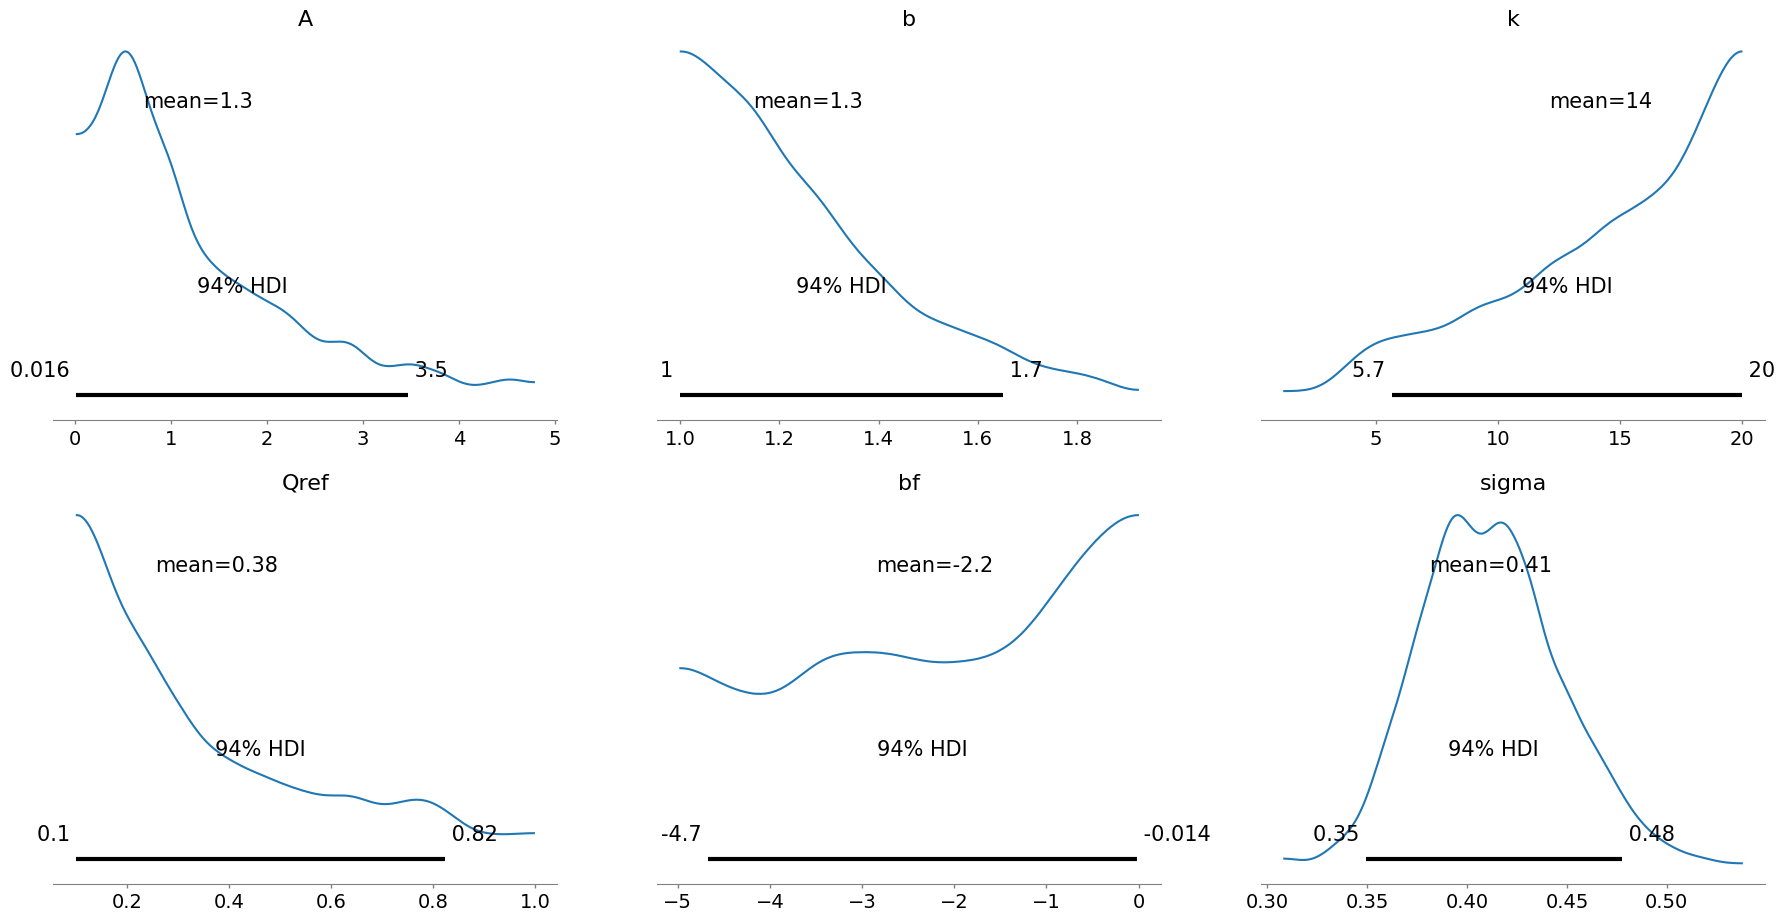

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
A       1.279  1.067   0.016    3.472      0.079    0.056     164.0     183.0   
b       1.258  0.206   1.000    1.650      0.012    0.009     338.0     210.0   
k      14.214  4.537   5.651   19.991      0.274    0.194     248.0     289.0   
Qref    0.376  0.239   0.100    0.823      0.015    0.010     301.0     420.0   
bf     -2.215  1.481  -4.671   -0.014      0.073    0.052     420.0     540.0   
sigma   0.412  0.035   0.349    0.477      0.002    0.001     399.0     716.0   

       r_hat  
A       1.00  
b       1.00  
k       1.01  
Qref    1.00  
bf      1.00  
sigma   1.00  


In [9]:
import pandas as pd
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt

gauge_id = 2231000
start_date = "1980-01-01"
end_date = "1980-01-31"

gauge_data = df[(df["gauge_id"] == gauge_id) & (df["date"] >= start_date) & (df["date"] <= end_date)]

# X (Precipitation) and y (Streamflow)
X = gauge_data["prcp"].values.astype(np.float64)  # Precipitation
y = gauge_data["streamflow"].values.astype(np.float64)  # Streamflow

# Define the ODE Model
def ode_model(x, rain, params):
    A, b, k, Qref, bf = params
    dt = 1
    x_next = pm.math.maximum(0, bf + x + (rain - Qref * ((x / (k + 1e-6)) ** (1 / (2 - b)))) * dt)
    Qeff = A * (Qref * ((x_next / (k + 1e-6)) ** (1 / (2 - b))))
    return Qeff

# Bayesian ODE Model
with pm.Model() as ode_bayesian_model:
    # Priors for parameters
    A = pm.Uniform("A", lower=0, upper=5)
    b = pm.Uniform("b", lower=1, upper=3)
    k = pm.Uniform("k", lower=1, upper=20)
    Qref = pm.Uniform("Qref", lower=0.1, upper=1)
    bf = pm.Uniform("bf", lower=-5, upper=0)

    # Convert parameters to tensor
    params = [A, b, k, Qref, bf]

    # Initial state (streamflow)
    x0 = pm.Normal("x0", mu=0, sigma=1)

    # Simulate ODE over all time steps
    Qeff = ode_model(x0, X, params)

    # Likelihood
    sigma = pm.HalfNormal("sigma", sigma=0.1)
    y_obs = pm.Normal("y_obs", mu=Qeff, sigma=sigma, observed=y)

    # Sampling from posterior
    trace = pm.sample(1000, tune=500, return_inferencedata=True)

# Posterior Plots
pm.plot_posterior(trace, var_names=["A", "b", "k", "Qref", "bf", "sigma"])
plt.show()

# Summary of Posterior Distributions
summary = pm.summary(trace, var_names=["A", "b", "k", "Qref", "bf", "sigma"])
print(summary)

Output()

Output()

ERROR:pymc.stats.convergence:There were 2625 divergences after tuning. Increase `target_accept` or reparameterize.


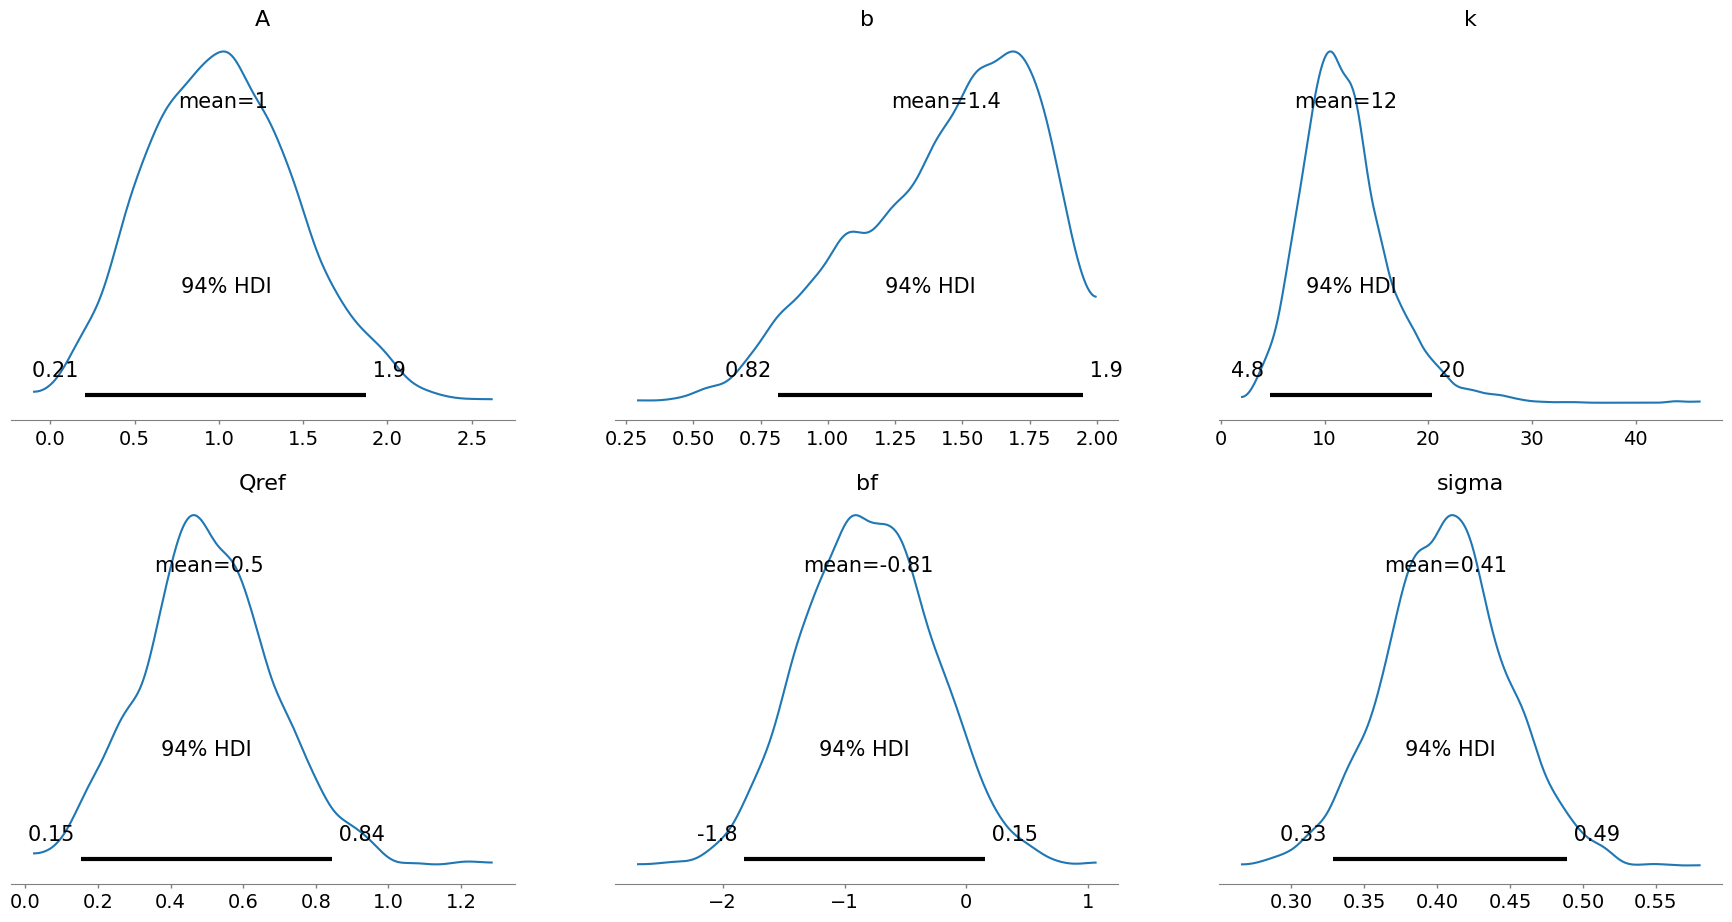

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
A       1.024  0.445   0.209    1.875      0.018    0.013     591.0     839.0   
b       1.439  0.328   0.815    1.947      0.017    0.012     407.0     890.0   
k      12.017  4.352   4.776   20.375      0.192    0.137     557.0     762.0   
Qref    0.505  0.186   0.154    0.844      0.010    0.007     377.0     751.0   
bf     -0.808  0.537  -1.828    0.151      0.020    0.014     727.0     869.0   
sigma   0.406  0.042   0.329    0.489      0.002    0.001     692.0     946.0   

       r_hat  
A       1.00  
b       1.00  
k       1.00  
Qref    1.00  
bf      1.01  
sigma   1.00  


In [11]:
import pandas as pd
import numpy as np
import pymc as pm

# Filter Data
gauge_id = 2231000
start_date = "1980-01-01"
end_date = "1980-01-31"

gauge_data = df[(df["gauge_id"] == gauge_id) & (df["date"] >= start_date) & (df["date"] <= end_date)]

# X (Precipitation) and y (Streamflow)
X = gauge_data["prcp"].values.astype(np.float64)  # Precipitation
y = gauge_data["streamflow"].values.astype(np.float64)  # Streamflow

# Define the ODE Model
def ode_model(x, rain, params):
    A, b, k, Qref, bf = params
    dt = 1.0  # Smaller time step
    x_next = pm.math.maximum(0, bf + x + (rain - Qref * ((x / (k + 1e-6)) ** (1 / (2 - b)))) * dt)
    x_next = pm.math.minimum(x_next, 1e6)  # Clamp to avoid extreme values
    Qeff = A * (Qref * ((x_next / (k + 1e-6)) ** (1 / (2 - b))))
    return Qeff

# Bayesian ODE Model
with pm.Model() as ode_bayesian_model:
    # Priors for parameters
    A = pm.Normal("A", mu=1, sigma=0.5)
    b = pm.Normal("b", mu=2, sigma=0.3)
    log_k = pm.Normal("log_k", mu=np.log(10), sigma=0.5)
    k = pm.Deterministic("k", pm.math.exp(log_k))
    Qref = pm.Normal("Qref", mu=0.5, sigma=0.2)
    bf = pm.Normal("bf", mu=-1, sigma=0.5)

    # Convert parameters to tensor
    params = [A, b, k, Qref, bf]

    # Initial state (streamflow)
    x0 = pm.Normal("x0", mu=0, sigma=1)

    # Simulate ODE over all time steps
    Qeff = ode_model(x0, X, params)

    # Likelihood
    sigma = pm.HalfNormal("sigma", sigma=0.1)
    y_obs = pm.Normal("y_obs", mu=Qeff, sigma=sigma, observed=y)

    # Sampling from posterior
    trace = pm.sample(2000, tune=1000, target_accept=0.99, return_inferencedata=True)

# Posterior Plots
pm.plot_posterior(trace, var_names=["A", "b", "k", "Qref", "bf", "sigma"])
plt.show()

# Summary of Posterior Distributions
summary = pm.summary(trace, var_names=["A", "b", "k", "Qref", "bf", "sigma"])
print(summary)

# # Posterior Predictive Sampling
# with ode_bayesian_model:
#     posterior_predictive = pm.sample_posterior_predictive(trace)

# # Extract and Plot Predictions
# y_pred_samples = posterior_predictive["y_obs"]
# y_pred = y_pred_samples.mean(axis=0)

# # Plot Observed vs Predicted Streamflow
# plt.figure(figsize=(10, 6))
# plt.scatter(X, y, label="Observed Data", color="black", alpha=0.7)
# plt.plot(X, y_pred, label="Mean Prediction", color="red", linewidth=2)
# plt.title(f"ODE Model: Precipitation vs Streamflow (Gauge ID: {gauge_id})")
# plt.xlabel("Precipitation (mm)")
# plt.ylabel("Streamflow (cfs)")
# plt.legend()
# plt.show()

In [5]:
file_path = '/content/drive/My Drive/CAMEL_ML/Full_dataset_Updated_Shah.csv'

gauge_ids_of_interest = [2231000]

years = 1

df = preprocess_data(file_path, gauge_ids_of_interest, years)

In [6]:
df

,gauge_id,date,dayl,prcp,srad,swe,tmax,tmin,vp,streamflow,lon_cen,lat_cen
1807891,2231000,1980-01-01,36288.00,0.00,220.72,0,12.59,4.04,803.20,0.325800,-82.25822,30.39226
1807892,2231000,1980-01-02,36288.00,0.00,329.11,0,15.47,-0.21,600.16,0.308652,-82.25822,30.39226
1807893,2231000,1980-01-03,36288.00,0.00,353.62,0,17.94,-1.20,560.03,0.291505,-82.25822,30.39226
1807894,2231000,1980-01-04,36288.00,5.86,242.37,0,17.05,3.72,800.18,0.282931,-82.25822,30.39226
1807895,2231000,1980-01-05,36327.36,0.00,263.27,0,14.33,3.69,800.00,0.288076,-82.25822,30.39226
...,...,...,...,...,...,...,...,...,...,...,...,...
1808252,2231000,1980-12-27,36258.77,0.00,159.81,0,7.30,0.50,630.05,0.219486,-82.25822,30.39226
1808253,2231000,1980-12-28,36282.51,0.81,140.57,0,6.99,1.14,650.88,0.212627,-82.25822,30.39226
1808254,2231000,1980-12-29,36288.00,5.03,123.28,0,11.58,4.67,853.23,0.205768,-82.25822,30.39226
1808255,2231000,1980-12-30,36288.00,0.00,267.12,0,16.06,3.73,800.01,0.205768,-82.25822,30.39226


In [11]:
# Example input: Replace this with your actual DataFrame
# Example structure for df
# df = pd.DataFrame({
#     "prcp": [1.2, 0.8, 1.5, 2.0, ...],  # Precipitation
#     "streamflow": [10.5, 12.3, 11.8, 13.1, ...]  # Observed Streamflow
# })

# Extract inputs
rain = df["prcp"].values  # Precipitation (input)
observed_streamflow = df["streamflow"].values  # Observed Streamflow

# ODE parameters for gauge ID 2231000
parameters = [0.3946042, 1.52383501, 14.83256936, 0.10079699, -1.90902814]

# Define the ODE function
def ode(par, rain, Temp=None, dt=1):
    n = len(rain)  # Number of time steps based on input data length
    x = np.zeros(n)  # Initialize state variable
    Qeff = np.zeros(n)  # Initialize effective discharge
    A, b, k, Qref, bf = par  # Unpack parameters
    epsilon = 1e-6  # Small constant to avoid division by zero

    # Compute state variable 'x' iteratively
    for i in range(n - 1):
        try:
            x[i + 1] = max(0, bf + x[i] +
                           (rain[i] - Qref * ((x[i] + epsilon) / (k + epsilon)) ** (1 / (2 - b))) * dt)
            # Clamp x[i+1] to avoid extremely large values
            x[i + 1] = min(x[i + 1], 1e6)
        except OverflowError:
            x[i + 1] = 0  # Reset to avoid instability

    # Effective discharge 'Qeff'
    try:
        Qeff[:] = A * (Qref * ((x + epsilon) / (k + epsilon)) ** (1 / (2 - b)))
    except OverflowError:
        Qeff[:] = np.nan  # Mark as invalid

    # Replace invalid Qeff values with zero
    Qeff[np.isnan(Qeff) | np.isinf(Qeff)] = 0

    return Qeff

# Compute predicted streamflow using the ODE function
predicted_streamflow = ode(parameters, rain)

# Create a DataFrame to compare observed and predicted streamflow
results = pd.DataFrame({
    "Precipitation": rain,
    "Observed Streamflow": observed_streamflow,
    "Predicted Streamflow": predicted_streamflow
})

# Display the first few rows of the results
print(results.head())

   Precipitation  Observed Streamflow  Predicted Streamflow
0           0.00             0.325800          3.461376e-17
1           0.00             0.308652          3.461376e-17
2           0.00             0.291505          3.461376e-17
3           5.86             0.282931          3.461376e-17
4           0.00             0.288076          2.472115e-03


<ipython-input-27-b7dbab37dfad>:14: RuntimeWarning: divide by zero encountered in scalar power
  x[i] = max(0, bf + x[i - 1] + (rain[i - 1] - Qref * (x[i - 1] / (k + 1e-6)) ** (1 / (2 - b))) * dt)
<ipython-input-27-b7dbab37dfad>:16: RuntimeWarning: divide by zero encountered in scalar power
  Qeff[i] = A * Qref * (x[i] / (k + 1e-6)) ** (1 / (2 - b))
<ipython-input-27-b7dbab37dfad>:16: RuntimeWarning: overflow encountered in scalar power
  Qeff[i] = A * Qref * (x[i] / (k + 1e-6)) ** (1 / (2 - b))
<ipython-input-27-b7dbab37dfad>:14: RuntimeWarning: overflow encountered in scalar power
  x[i] = max(0, bf + x[i - 1] + (rain[i - 1] - Qref * (x[i - 1] / (k + 1e-6)) ** (1 / (2 - b))) * dt)


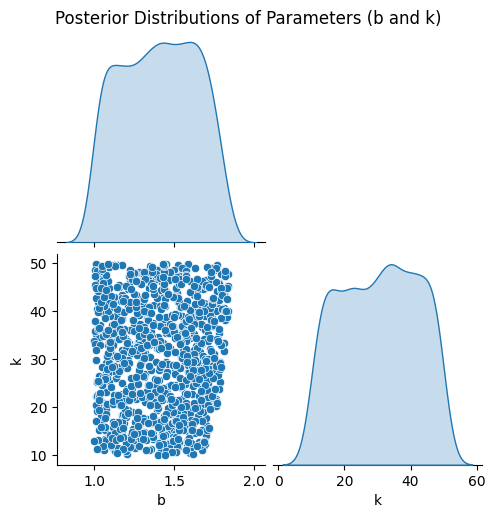

Posterior Means:
b     1.401355
k    30.481605
dtype: float64


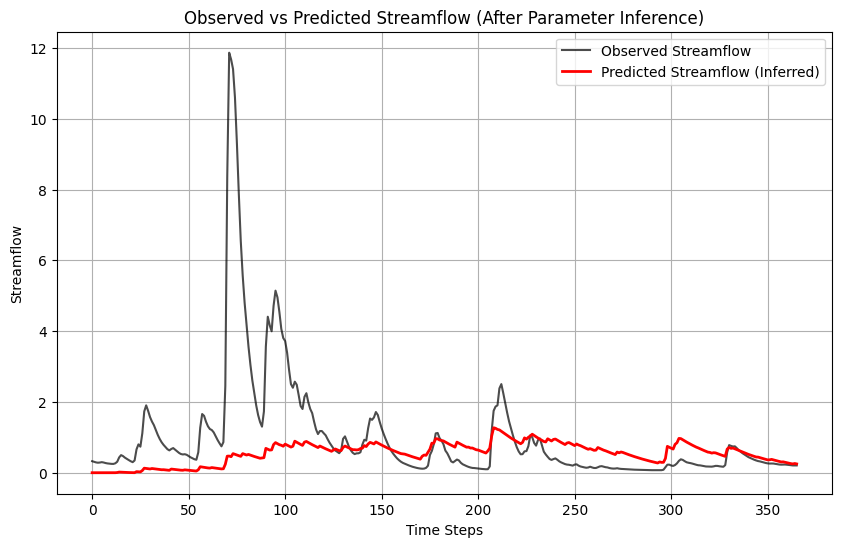

In [27]:
# Define the ODE model with clamping
def ode(par, rain, dt=1):
    A, b, k, Qref, bf = par
    n = len(rain)
    x = np.zeros(n)
    Qeff = np.zeros(n)

    for i in range(1, n):
        x[i] = max(0, bf + x[i - 1] + (rain[i - 1] - Qref * (x[i - 1] / (k + 1e-6)) ** (1 / (2 - b))) * dt)
        x[i] = min(x[i], 1e6)  # Clamp x to avoid large values
        Qeff[i] = A * Qref * (x[i] / (k + 1e-6)) ** (1 / (2 - b))
        Qeff[i] = min(Qeff[i], 1e6)  # Clamp Qeff to avoid large values

    return Qeff

# Distance metric with overflow handling
def dist_metric1(d, x):
    try:
        dist = np.sum((d - x)**2) / np.sum((d - np.mean(d))**2)
        return dist if not np.isnan(dist) else np.inf
    except:
        return np.inf

# Use df['prcp'] for rain and df['streamflow'] for observed streamflow
n_obs = len(df)
rain_obs = df['prcp'].values  # Precipitation
discharge_obs = df['streamflow'].values  # Observed streamflow

# Define priors for parameters
priors = {
    "b": [1.0, 5.0],  # Widened prior for 'b'
    "k": [10.0, 50.0]  # Widened prior for 'k'
}

# Approximate Bayesian Computation (ABC) sampling
def sample_parameters(rain, observed_streamflow, prior_ranges, n_samples=5000, threshold=1.0):
    samples = []
    for _ in range(n_samples):
        # Sample parameters from the prior
        b_sample = np.random.uniform(*prior_ranges["b"])
        k_sample = np.random.uniform(*prior_ranges["k"])
        params = [0.3946042, b_sample, k_sample, 0.10079699, -1.90902814]

        # Simulate streamflow
        predicted_streamflow = ode(params, rain)

        # Calculate distance metric
        distance = dist_metric1(observed_streamflow, predicted_streamflow)

        # Accept/reject samples based on threshold
        if distance < threshold:
            samples.append([b_sample, k_sample])

    return np.array(samples)

# Perform parameter inference
samples = sample_parameters(rain_obs, discharge_obs, priors, n_samples=5000, threshold=2.0)

# Check if samples were generated
if len(samples) == 0:
    print("No samples accepted. Try increasing the threshold or changing the priors.")
else:
    # Visualize posterior distributions
    samples_df = pd.DataFrame(samples, columns=["b", "k"])
    sns.pairplot(samples_df, diag_kind="kde", corner=True)
    plt.suptitle("Posterior Distributions of Parameters (b and k)", y=1.02)
    plt.show()

    # Summary of posterior means
    posterior_means = samples_df.mean()
    print("Posterior Means:")
    print(posterior_means)

    # Evaluate model with inferred parameters
    inferred_params = [0.3946042, posterior_means["b"], posterior_means["k"], 0.10079699, -1.90902814]
    predicted_streamflow_inferred = ode(inferred_params, rain_obs)

    # Plot observed vs predicted streamflow
    plt.figure(figsize=(10, 6))
    plt.plot(discharge_obs, label="Observed Streamflow", color="black", alpha=0.7)
    plt.plot(predicted_streamflow_inferred, label="Predicted Streamflow (Inferred)", color="red", linewidth=2)
    plt.title("Observed vs Predicted Streamflow (After Parameter Inference)")
    plt.xlabel("Time Steps")
    plt.ylabel("Streamflow")
    plt.legend()
    plt.grid(True)
    plt.show()

<ipython-input-32-452e714b4f42>:14: RuntimeWarning: divide by zero encountered in scalar power
  x[i] = max(0, bf + x[i - 1] + (rain[i - 1] - Qref * (x[i - 1] / (k + 1e-6)) ** (1 / (2 - b))) * dt)
<ipython-input-32-452e714b4f42>:16: RuntimeWarning: divide by zero encountered in scalar power
  Qeff[i] = A * Qref * (x[i] / (k + 1e-6)) ** (1 / (2 - b))
<ipython-input-32-452e714b4f42>:16: RuntimeWarning: overflow encountered in scalar power
  Qeff[i] = A * Qref * (x[i] / (k + 1e-6)) ** (1 / (2 - b))
<ipython-input-32-452e714b4f42>:14: RuntimeWarning: overflow encountered in scalar power
  x[i] = max(0, bf + x[i - 1] + (rain[i - 1] - Qref * (x[i - 1] / (k + 1e-6)) ** (1 / (2 - b))) * dt)


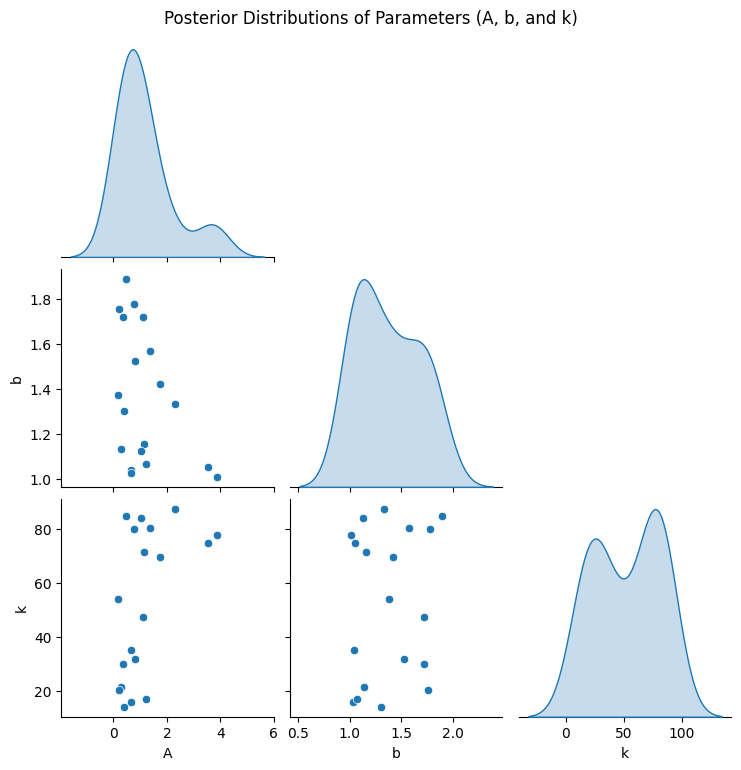

Posterior Means:
A     1.159552
b     1.367958
k    52.465883
dtype: float64


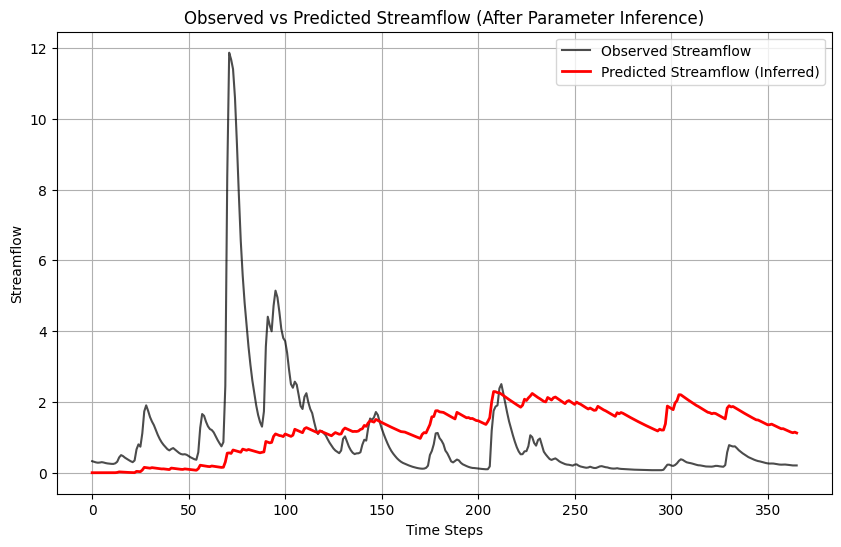

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the ODE model with clamping
def ode(par, rain, dt=1):
    A, b, k, Qref, bf = par
    n = len(rain)
    x = np.zeros(n)
    Qeff = np.zeros(n)

    for i in range(1, n):
        x[i] = max(0, bf + x[i - 1] + (rain[i - 1] - Qref * (x[i - 1] / (k + 1e-6)) ** (1 / (2 - b))) * dt)
        x[i] = min(x[i], 1e6)  # Clamp x to avoid large values
        Qeff[i] = A * Qref * (x[i] / (k + 1e-6)) ** (1 / (2 - b))
        Qeff[i] = min(Qeff[i], 1e6)  # Clamp Qeff to avoid large values

    return Qeff

# Distance metric with overflow handling
def dist_metric1(d, x):
    try:
        dist = np.sum((d - x)**2) / np.sum((d - np.mean(d))**2)
        return dist if not np.isnan(dist) else np.inf
    except:
        return np.inf

# Use df['prcp'] for rain and df['streamflow'] for observed streamflow
n_obs = len(df)
rain_obs = df['prcp'].values  # Precipitation
discharge_obs = df['streamflow'].values  # Observed streamflow

# Define priors for parameters
priors = {
    "A": [0.1, 20.0],  # Prior for parameter A
    "b": [1.0, 20.0],  # Prior for parameter b
    "k": [10.0, 88.0]  # Prior for parameter k
}

true_params = [0.3946042, 1.52383501, 14.83256936, 0.10079699, -1.90902814]

# Approximate Bayesian Computation (ABC) sampling
def sample_parameters(rain, observed_streamflow, prior_ranges, n_samples=5000, threshold=1.0):
    samples = []
    for _ in range(n_samples):
        # Sample parameters from the prior
        A_sample = np.random.uniform(*prior_ranges["A"])
        b_sample = np.random.uniform(*prior_ranges["b"])
        k_sample = np.random.uniform(*prior_ranges["k"])
        params = [A_sample, b_sample, k_sample, 0.10079699, -1.90902814]

        # Simulate streamflow
        predicted_streamflow = ode(params, rain)

        # Calculate distance metric
        distance = dist_metric1(observed_streamflow, predicted_streamflow)

        # Accept/reject samples based on threshold
        if distance < threshold:
            samples.append([A_sample, b_sample, k_sample])

    return np.array(samples)

# Perform parameter inference
samples = sample_parameters(rain_obs, discharge_obs, priors, n_samples=5000, threshold=2.0)

# Check if samples were generated
if len(samples) == 0:
    print("No samples accepted. Try increasing the threshold or changing the priors.")
else:
    # Visualize posterior distributions
    samples_df = pd.DataFrame(samples, columns=["A", "b", "k"])
    sns.pairplot(samples_df, diag_kind="kde", corner=True)
    plt.suptitle("Posterior Distributions of Parameters (A, b, and k)", y=1.02)
    plt.show()

    # Summary of posterior means
    posterior_means = samples_df.mean()
    print("Posterior Means:")
    print(posterior_means)

    # Evaluate model with inferred parameters
    inferred_params = [
        posterior_means["A"],
        posterior_means["b"],
        posterior_means["k"],
        0.10079699,
        -1.90902814
    ]
    predicted_streamflow_inferred = ode(inferred_params, rain_obs)

    # Plot observed vs predicted streamflow
    plt.figure(figsize=(10, 6))
    plt.plot(discharge_obs, label="Observed Streamflow", color="black", alpha=0.7)
    plt.plot(predicted_streamflow_inferred, label="Predicted Streamflow (Inferred)", color="red", linewidth=2)
    plt.title("Observed vs Predicted Streamflow (After Parameter Inference)")
    plt.xlabel("Time Steps")
    plt.ylabel("Streamflow")
    plt.legend()
    plt.grid(True)
    plt.show()

<ipython-input-33-28250c272de3>:14: RuntimeWarning: divide by zero encountered in scalar power
  x[i] = max(0, bf + x[i - 1] + (rain[i - 1] - Qref * (x[i - 1] / (k + 1e-6)) ** (1 / (2 - b))) * dt)
<ipython-input-33-28250c272de3>:16: RuntimeWarning: divide by zero encountered in scalar power
  Qeff[i] = A * Qref * (x[i] / (k + 1e-6)) ** (1 / (2 - b))


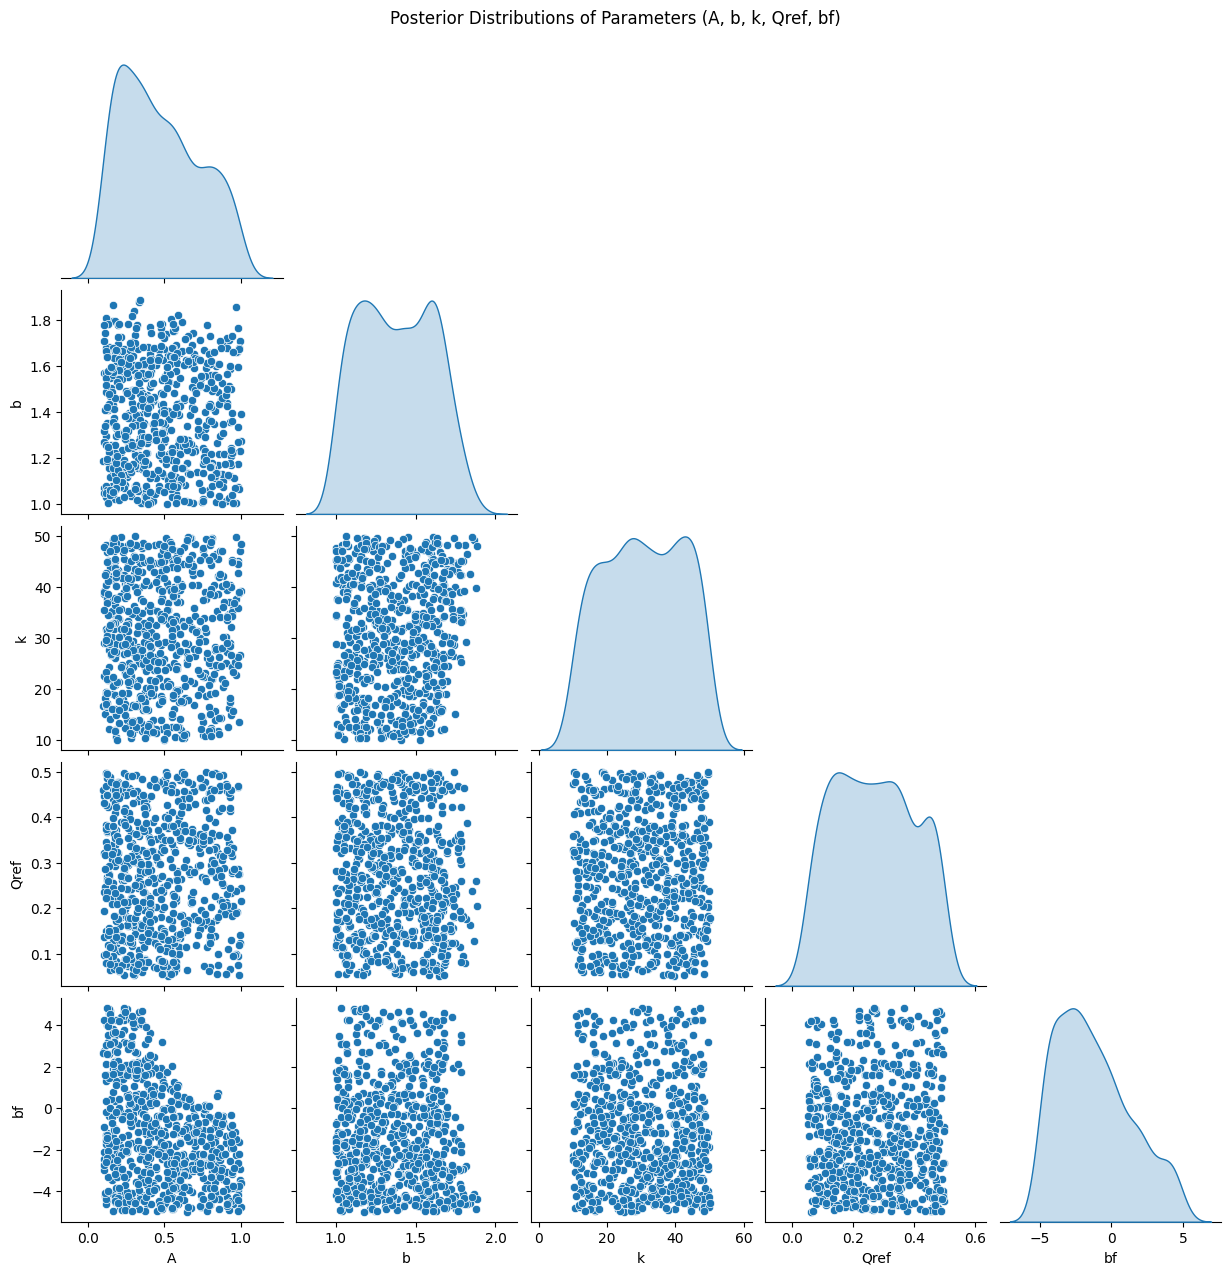

Posterior Means:
A        0.473540
b        1.380583
k       30.516694
Qref     0.270520
bf      -1.235359
dtype: float64


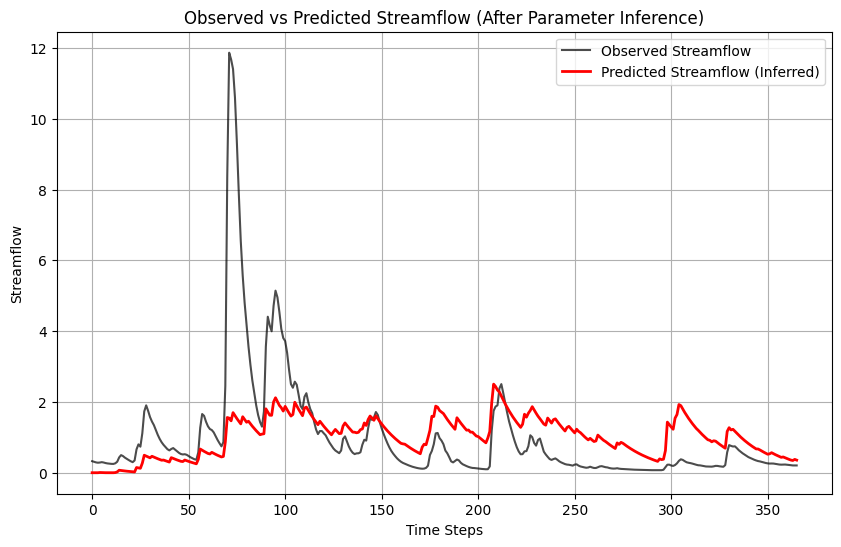

In [33]:
def ode(par, rain, dt=1):
    A, b, k, Qref, bf = par
    n = len(rain)
    x = np.zeros(n)
    Qeff = np.zeros(n)

    for i in range(1, n):
        x[i] = max(0, bf + x[i - 1] + (rain[i - 1] - Qref * (x[i - 1] / (k + 1e-6)) ** (1 / (2 - b))) * dt)
        x[i] = min(x[i], 1e6)  # Clamp x to avoid large values
        Qeff[i] = A * Qref * (x[i] / (k + 1e-6)) ** (1 / (2 - b))
        Qeff[i] = min(Qeff[i], 1e6)  # Clamp Qeff to avoid large values

    return Qeff

# Distance metric with overflow handling
def dist_metric1(d, x):
    try:
        dist = np.sum((d - x)**2) / np.sum((d - np.mean(d))**2)
        return dist if not np.isnan(dist) else np.inf
    except:
        return np.inf

# Use df['prcp'] for rain and df['streamflow'] for observed streamflow
n_obs = len(df)
rain_obs = df['prcp'].values  # Precipitation
discharge_obs = df['streamflow'].values  # Observed streamflow

# Define priors for parameters
priors = {
    "A": [0.1, 1.0],        # Prior for parameter A
    "b": [1.0, 5.0],        # Prior for parameter b
    "k": [10.0, 50.0],      # Prior for parameter k
    "Qref": [0.05, 0.5],    # Prior for parameter Qref
    "bf": [-5.0, 5.0]       # Prior for parameter bf
}

# Approximate Bayesian Computation (ABC) sampling
def sample_parameters(rain, observed_streamflow, prior_ranges, n_samples=5000, threshold=1.0):
    samples = []
    for _ in range(n_samples):
        # Sample parameters from the prior
        A_sample = np.random.uniform(*prior_ranges["A"])
        b_sample = np.random.uniform(*prior_ranges["b"])
        k_sample = np.random.uniform(*prior_ranges["k"])
        Qref_sample = np.random.uniform(*prior_ranges["Qref"])
        bf_sample = np.random.uniform(*prior_ranges["bf"])
        params = [A_sample, b_sample, k_sample, Qref_sample, bf_sample]

        # Simulate streamflow
        predicted_streamflow = ode(params, rain)

        # Calculate distance metric
        distance = dist_metric1(observed_streamflow, predicted_streamflow)

        # Accept/reject samples based on threshold
        if distance < threshold:
            samples.append([A_sample, b_sample, k_sample, Qref_sample, bf_sample])

    return np.array(samples)

# Perform parameter inference
samples = sample_parameters(rain_obs, discharge_obs, priors, n_samples=5000, threshold=2.0)

# Check if samples were generated
if len(samples) == 0:
    print("No samples accepted. Try increasing the threshold or changing the priors.")
else:
    # Visualize posterior distributions
    samples_df = pd.DataFrame(samples, columns=["A", "b", "k", "Qref", "bf"])
    sns.pairplot(samples_df, diag_kind="kde", corner=True)
    plt.suptitle("Posterior Distributions of Parameters (A, b, k, Qref, bf)", y=1.02)
    plt.show()

    # Summary of posterior means
    posterior_means = samples_df.mean()
    print("Posterior Means:")
    print(posterior_means)

    # Evaluate model with inferred parameters
    inferred_params = [
        posterior_means["A"],
        posterior_means["b"],
        posterior_means["k"],
        posterior_means["Qref"],
        posterior_means["bf"]
    ]
    predicted_streamflow_inferred = ode(inferred_params, rain_obs)

    # Plot observed vs predicted streamflow
    plt.figure(figsize=(10, 6))
    plt.plot(discharge_obs, label="Observed Streamflow", color="black", alpha=0.7)
    plt.plot(predicted_streamflow_inferred, label="Predicted Streamflow (Inferred)", color="red", linewidth=2)
    plt.title("Observed vs Predicted Streamflow (After Parameter Inference)")
    plt.xlabel("Time Steps")
    plt.ylabel("Streamflow")
    plt.legend()
    plt.grid(True)
    plt.show()

In [29]:
# df = pd.read_csv('/content/drive/My Drive/CAMEL_ML/Full_dataset_Updated_Shah.csv')
# print(df['gauge_id'].unique())